# Spotify Most Popular Songs
Kacper Osmola 2025

The data set is from:
https://www.kaggle.com/datasets/rishabhpancholi1302/spotify-most-popular-songs-dataset/code

We have a dataset of plenty of songs from Spotify. Can we build a system, which will find most similar songs to one chosen song?

# Dataset

In [3]:
!pip install scikit-learn

In [4]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv('songs.csv')
df

,Unnamed: 0,track_id,track_name,track_artist,track_popularity,track_album_release_date,playlist_genre,danceability,energy,key,...,track_artist_merged,lyrics,artist_name,tags,tags_tokenized,doc_vector,combined_vector,cluster,image_url,spotify_url
0,0,6oJ6le65B3SEqPwMRNXWjY,higher love,Kygo,0.500000,2019-06-28,Pop,0.632680,0.667346,0.727273,...,kygo,"['bring', 'me', 'higher', 'love,', 'love', '',...",Kygo,bring higher love love bring higher love think...,"['bring', 'higher', 'love', 'love', 'bring', '...",[-0.1148182 0.27755967 0.27891365 0.143460...,[-0.1148182 0.27755967 0.27891365 0.143460...,3,https://i.scdn.co/image/ab67616d0000b2737c8977...,https://open.spotify.com/track/6oJ6le65B3SEqPw...
1,1,3yNZ5r3LKfdmjoS3gkhUCT,bad guy (with justin bieber),Billieeilish,0.318182,2019-07-11,Pop,0.602614,0.425904,0.000000,...,billie eilish,"['yeah,', 'yeah', '', 'oh,', 'ah', '', 'white'...",Billie Eilish,yeah yeah oh ah white shirt red bloody nose sl...,"['yeah', 'yeah', 'oh', 'ah', 'white', 'shirt',...",[-2.95320839e-01 -2.59309914e-03 3.84592146e-...,[-2.95320839e-01 -2.59309914e-03 3.84592146e-...,1,https://i.scdn.co/image/ab67616d0000b273a69b8b...,https://open.spotify.com/track/3yNZ5r3LKfdmjoS...
2,2,0qc4QlcCxVTGyShurEv1UU,post malone (feat. rani),Samfeldt,0.318182,2019-05-24,Pop,0.498039,0.628716,0.636364,...,sam feldt,"['one', 'more', 'drink,', 'got', 'one', 'more'...",Sam Feldt,one drink got one bacardi one dance afterparty...,"['one', 'drink', 'got', 'one', 'bacardi', 'one...",[-0.1616459 0.21872164 0.3755187 0.116120...,[-0.1616459 0.21872164 0.37551871 0.116120...,3,https://i.scdn.co/image/ab67616d0000b27354de16...,https://open.spotify.com/track/0qc4QlcCxVTGySh...
3,3,4PkIDTPGedm0enzdvilLNd,sixteen,Elliegoulding,0.227273,2019-04-12,Pop,0.601307,0.799335,0.727273,...,ellie goulding,"['(sixteen)', '', '(sixteen)', '', 'do', 'you'...",Ellie Goulding,sixteen sixteen remember moved mum said love s...,"['sixteen', 'sixteen', 'remember', 'moved', 'm...",[-0.17123666 0.15697554 0.2319686 0.190121...,[-0.17123666 0.15697554 0.2319686 0.190121...,3,https://i.scdn.co/image/ab67616d0000b27394181f...,https://open.spotify.com/track/4PkIDTPGedm0enz...
4,4,5PYQUBXc7NYeI1obMKSJK0,never really over,Katyperry,0.409091,2019-05-31,Pop,0.733333,0.886254,0.727273,...,katy perry,"[""i'm"", 'losing', 'my', 'self', 'control', '',...",Katy Perry,im losing self control yeah youre starting tri...,"['im', 'losing', 'self', 'control', 'yeah', 'y...",[-0.26988247 0.21529263 0.3686135 0.180054...,[-0.26988247 0.21529263 0.36861351 0.180054...,3,https://i.scdn.co/image/ab67616d0000b2739bea3b...,https://open.spotify.com/track/5PYQUBXc7NYeI1o...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
895,895,4gDvg62vG96w0qJaF6wzcd,a culpa é do meu grau (feat. zé neto & cristia...,Diego&victorhugo,0.090909,2019-03-22,Edm,0.435294,0.879815,0.545455,...,diego & victor hugo,"['vamo', 'assim', 'ó', '', 'segura', 'assim', ...",Diego & Victor Hugo,vamo assim segura assim moada pode dar um grit...,"['vamo', 'assim', 'segura', 'assim', 'moada', ...",[-3.50417316e-01 2.76123464e-01 9.81263742e-...,[-3.50417316e-01 2.76123464e-01 9.81263742e-...,3,https://i.scdn.co/image/ab67616d0000b273f4bcb4...,https://open.spotify.com/track/4gDvg62vG96w0qJ...
896,896,1uryupl9hqVZYurJwH4G9k,3 batidas - ao vivo,Guilherme&benuto,0.272727,2019-08-16,Edm,0.448366,0.700612,0.727273,...,guilherme & benuto,"['pensa', 'numa', 'história...', '', 'coitado'...",Guilherme & Benuto,pensa numa histria coitado eu rindo mas desesp...,"['pensa', 'numa', 'histria', 'coitado', 'eu', ...",[-1.92822352e-01 1.54831573e-01 7.25356638e-...,[-1.92822352e-01 1.54831573e-01 7.25356638e-...,3,https://i.scdn.co/image/ab67616d0000b273826f45...,https://open.spotify.com/track/1uryupl9hqVZYur...
897,897,2meEiZKWkiN28gITzFwQo5,into you,Arianagrande,0.136364,2016-05-20,Edm,0.541176,0.727439,0.818182,...,ariana grande,"[""i'm"", 'so', 'into', 'you', '', 'i', 'can', '...",Ariana Grande,im bare

# Analysis

## Brief descripition

Dataset contains 900 songs and 28 atributes. Those are:
- track_id (int) - id of the song on Spotify
- track_name (string) - song's name
- track_artist (string) - artist's name
- track_popularity (float) - spotify popularity score (from 0 to 1)
- track_album_release (date year-month-day) song's release date
- playlist_genre (string) song's genre (pop, rap etc.)
- danceability – How suitable a track is for dancing (0.0 – 1.0).
- energy – Intensity and activity level of a song (0.0 – 1.0).
- key – Musical key (0.0 - 1.0)
- loudness – Overall loudness in decibels (normalized 0.0 - 1.0)
- mode - musical mode (major - 0, minor - 1)
- speechiness – Presence of spoken words in the track (0.0 – 1.0).
- acousticness – Probability that a track is acoustic (0.0 – 1.0).
- instrumentalness – Predicts if a track is instrumental (0.0 – 1.0).
- liveness – Probability of a live audience (0.0 – 1.0).
- valence – Musical positivity or happiness (0.0 – 1.0).
- tempo – Beats per minute (BPM) of the track (normalized 0.0 - 1.0)
- duration_ms (int) - song's length in ms
- track_artist_merged(string) lower case artist name
- lyrics (list of strings) lyrics, each word as a string in the list
- artist_name (string) again, artist's name
- tags (string) lyrics in single strings
- tags_tokenized (list of string) lyrics in a list but without whitespaces
- image_url (string) link to the image of the song
- spotify_url (string) link to the song on the spotify

Attributes: doc_vector, combined_vector and cluster are not described but we don't need them in out analysis.

## Data preparation

Let's divide date into year, month and day

In [6]:
df['year'] = df['track_album_release_date'].str.split('-', expand=True)[0]
df['month'] = df['track_album_release_date'].str.split('-', expand=True)[1]
df['day'] = df['track_album_release_date'].str.split('-', expand=True)[2]
df

,Unnamed: 0,track_id,track_name,track_artist,track_popularity,track_album_release_date,playlist_genre,danceability,energy,key,...,tags,tags_tokenized,doc_vector,combined_vector,cluster,image_url,spotify_url,year,month,day
0,0,6oJ6le65B3SEqPwMRNXWjY,higher love,Kygo,0.500000,2019-06-28,Pop,0.632680,0.667346,0.727273,...,bring higher love love bring higher love think...,"['bring', 'higher', 'love', 'love', 'bring', '...",[-0.1148182 0.27755967 0.27891365 0.143460...,[-0.1148182 0.27755967 0.27891365 0.143460...,3,https://i.scdn.co/image/ab67616d0000b2737c8977...,https://open.spotify.com/track/6oJ6le65B3SEqPw...,2019,06,28
1,1,3yNZ5r3LKfdmjoS3gkhUCT,bad guy (with justin bieber),Billieeilish,0.318182,2019-07-11,Pop,0.602614,0.425904,0.000000,...,yeah yeah oh ah white shirt red bloody nose sl...,"['yeah', 'yeah', 'oh', 'ah', 'white', 'shirt',...",[-2.95320839e-01 -2.59309914e-03 3.84592146e-...,[-2.95320839e-01 -2.59309914e-03 3.84592146e-...,1,https://i.scdn.co/image/ab67616d0000b273a69b8b...,https://open.spotify.com/track/3yNZ5r3LKfdmjoS...,2019,07,11
2,2,0qc4QlcCxVTGyShurEv1UU,post malone (feat. rani),Samfeldt,0.318182,2019-05-24,Pop,0.498039,0.628716,0.636364,...,one drink got one bacardi one dance afterparty...,"['one', 'drink', 'got', 'one', 'bacardi', 'one...",[-0.1616459 0.21872164 0.3755187 0.116120...,[-0.1616459 0.21872164 0.37551871 0.116120...,3,https://i.scdn.co/image/ab67616d0000b27354de16...,https://open.spotify.com/track/0qc4QlcCxVTGySh...,2019,05,24
3,3,4PkIDTPGedm0enzdvilLNd,sixteen,Elliegoulding,0.227273,2019-04-12,Pop,0.601307,0.799335,0.727273,...,sixteen sixteen remember moved mum said love s...,"['sixteen', 'sixteen', 'remember', 'moved', 'm...",[-0.17123666 0.15697554 0.2319686 0.190121...,[-0.17123666 0.15697554 0.2319686 0.190121...,3,https://i.scdn.co/image/ab67616d0000b27394181f...,https://open.spotify.com/track/4PkIDTPGedm0enz...,2019,04,12
4,4,5PYQUBXc7NYeI1obMKSJK0,never really over,Katyperry,0.409091,2019-05-31,Pop,0.733333,0.886254,0.727273,...,im losing self control yeah youre starting tri...,"['im', 'losing', 'self', 'control', 'yeah', 'y...",[-0.26988247 0.21529263 0.3686135 0.180054...,[-0.26988247 0.21529263 0.36861351 0.180054...,3,https://i.scdn.co/image/ab67616d0000b2739bea3b...,https://open.spotify.com/track/5PYQUBXc7NYeI1o...,2019,05,31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
895,895,4gDvg62vG96w0qJaF6wzcd,a culpa é do meu grau (feat. zé neto & cristia...,Diego&victorhugo,0.090909,2019-03-22,Edm,0.435294,0.879815,0.545455,...,vamo assim segura assim moada pode dar um grit...,"['vamo', 'assim', 'segura', 'assim', 'moada', ...",[-3.50417316e-01 2.76123464e-01 9.81263742e-...,[-3.50417316e-01 2.76123464e-01 9.81263742e-...,3,https://i.scdn.co/image/ab67616d0000b273f4bcb4...,https://open.spotify.com/track/4gDvg62vG96w0qJ...,2019,03,22
896,896,1uryupl9hqVZYurJwH4G9k,3 batidas - ao vivo,Guilherme&benuto,0.272727,2019-08-16,Edm,0.448366,0.700612,0.727273,...,pensa numa histria coitado eu rindo mas desesp...,"['pensa', 'numa', 'histria', 'coitado', 'eu', ...",[-1.92822352e-01 1.54831573e-01 7.25356638e-...,[-1.92822352e-01 1.54831573e-01 7.25356638e-...,3,https://i.scdn.co/image/ab67616d0000b273826f45...,https://open.spotify.com/track/1uryupl9hqVZYur...,2019,08,16
897,897,2meEiZKWkiN28gITzFwQo5,into you,Arianagrande,0.136364,2016-05-20,Edm,0.541176,0.727439,0.818182,...,im barely breathe wan na fall deep close aint ...,"['im', 'barely', 'breathe', 'wan', 'na', 'fall...",[-1.26169592e-01 1.99980661e-01 2.91309446e-...,[-1.26169592e-01 1.99980661e-01 2.91309446e-...,3,https://i.scdn.co/image/ab67616d0000b2735f9393...,https://open.spotify.com/track/2meEiZKWkiN28gI...,2016,05,20
898,898,1ZLrDPgR7mvuTco3rQK8Pk,way back home (feat. conor maynard) - sam feld...,Shaun,0.045455,2018-12-21,Edm,0.690196,0.741389,0.909091,...,remember told matter go ill never leave side n...,"['remember', 'told', 'matter', 'go', 'ill', 'n...",[-1.21940374e-01 3.29611808e-01 3.4

Let's divide genres into dummie variables

In [7]:
df_dummies = pd.get_dummies(df, columns=['playlist_genre'])
df_dummies['playlist_genre'] = df['playlist_genre']
df_dummies

,Unnamed: 0,track_id,track_name,track_artist,track_popularity,track_album_release_date,danceability,energy,key,loudness,...,year,month,day,playlist_genre_Edm,playlist_genre_Latin,playlist_genre_Pop,playlist_genre_R&b,playlist_genre_Rap,playlist_genre_Rock,playlist_genre
0,0,6oJ6le65B3SEqPwMRNXWjY,higher love,Kygo,0.500000,2019-06-28,0.632680,0.667346,0.727273,0.680129,...,2019,06,28,False,False,True,False,False,False,Pop
1,1,3yNZ5r3LKfdmjoS3gkhUCT,bad guy (with justin bieber),Billieeilish,0.318182,2019-07-11,0.602614,0.425904,0.000000,0.504094,...,2019,07,11,False,False,True,False,False,False,Pop
2,2,0qc4QlcCxVTGyShurEv1UU,post malone (feat. rani),Samfeldt,0.318182,2019-05-24,0.498039,0.628716,0.636364,0.821136,...,2019,05,24,False,False,True,False,False,False,Pop
3,3,4PkIDTPGedm0enzdvilLNd,sixteen,Elliegoulding,0.227273,2019-04-12,0.601307,0.799335,0.727273,0.753612,...,2019,04,12,False,False,True,False,False,False,Pop
4,4,5PYQUBXc7NYeI1obMKSJK0,never really over,Katyperry,0.409091,2019-05-31,0.733333,0.886254,0.727273,0.781608,...,2019,05,31,False,False,True,False,False,False,Pop
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
895,895,4gDvg62vG96w0qJaF6wzcd,a culpa é do meu grau (feat. zé neto & cristia...,Diego&victorhugo,0.090909,2019-03-22,0.435294,0.879815,0.545455,0.842229,...,2019,03,22,True,False,False,False,False,False,Edm
896,896,1uryupl9hqVZYurJwH4G9k,3 batidas - ao vivo,Guilherme&benuto,0.272727,2019-08-16,0.448366,0.700612,0.727273,0.754041,...,2019,08,16,True,False,False,False,False,False,Edm
897,897,2meEiZKWkiN28gITzFwQo5,into you,Arianagrande,0.136364,2016-05-20,0.541176,0.727439,0.818182,0.731961,...,2016,05,20,True,False,False,False,False,False,Edm
898,898,1ZLrDPgR7mvuTco3rQK8Pk,way back home (feat. conor maynard) - sam feld...,Shaun,0.045455,2018-12-21,0.690196,0.741389,0.909091,0.780493,...,2018,12,21,True,False,False,False,False,False,Edm


Let's check if there are no null values

In [8]:
df_dummies.isnull().any()

,0
Unnamed: 0,False
track_id,False
track_name,False
track_artist,False
track_popularity,False
track_album_release_date,False
danceability,False
energy,False
key,False
loudness,False


As we see, in some rows there are no day and month. Let's make a database without null values

In [9]:
df_not_null = df_dummies[df_dummies['day'].notnull() & df_dummies['month'].notnull()]
df_not_null

,Unnamed: 0,track_id,track_name,track_artist,track_popularity,track_album_release_date,danceability,energy,key,loudness,...,year,month,day,playlist_genre_Edm,playlist_genre_Latin,playlist_genre_Pop,playlist_genre_R&b,playlist_genre_Rap,playlist_genre_Rock,playlist_genre
0,0,6oJ6le65B3SEqPwMRNXWjY,higher love,Kygo,0.500000,2019-06-28,0.632680,0.667346,0.727273,0.680129,...,2019,06,28,False,False,True,False,False,False,Pop
1,1,3yNZ5r3LKfdmjoS3gkhUCT,bad guy (with justin bieber),Billieeilish,0.318182,2019-07-11,0.602614,0.425904,0.000000,0.504094,...,2019,07,11,False,False,True,False,False,False,Pop
2,2,0qc4QlcCxVTGyShurEv1UU,post malone (feat. rani),Samfeldt,0.318182,2019-05-24,0.498039,0.628716,0.636364,0.821136,...,2019,05,24,False,False,True,False,False,False,Pop
3,3,4PkIDTPGedm0enzdvilLNd,sixteen,Elliegoulding,0.227273,2019-04-12,0.601307,0.799335,0.727273,0.753612,...,2019,04,12,False,False,True,False,False,False,Pop
4,4,5PYQUBXc7NYeI1obMKSJK0,never really over,Katyperry,0.409091,2019-05-31,0.733333,0.886254,0.727273,0.781608,...,2019,05,31,False,False,True,False,False,False,Pop
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
895,895,4gDvg62vG96w0qJaF6wzcd,a culpa é do meu grau (feat. zé neto & cristia...,Diego&victorhugo,0.090909,2019-03-22,0.435294,0.879815,0.545455,0.842229,...,2019,03,22,True,False,False,False,False,False,Edm
896,896,1uryupl9hqVZYurJwH4G9k,3 batidas - ao vivo,Guilherme&benuto,0.272727,2019-08-16,0.448366,0.700612,0.727273,0.754041,...,2019,08,16,True,False,False,False,False,False,Edm
897,897,2meEiZKWkiN28gITzFwQo5,into you,Arianagrande,0.136364,2016-05-20,0.541176,0.727439,0.818182,0.731961,...,2016,05,20,True,False,False,False,False,False,Edm
898,898,1ZLrDPgR7mvuTco3rQK8Pk,way back home (feat. conor maynard) - sam feld...,Shaun,0.045455,2018-12-21,0.690196,0.741389,0.909091,0.780493,...,2018,12,21,True,False,False,False,False,False,Edm


As we see, there are 881 rows, so only 19 songs did not have day or month

And quickly check the data

In [10]:
df_dummies.describe()

,Unnamed: 0,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,liveness,valence,tempo,duration_ms,cluster
count,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000
mean,449.500000,0.199545,0.623394,0.640775,0.484444,0.726726,0.574444,0.115008,0.225910,0.160050,0.518995,0.414709,211372.507778,2.003333
std,259.951919,0.199525,0.183919,0.181130,0.334353,0.111564,0.494702,0.133004,0.238884,0.139023,0.237509,0.208335,45092.774311,1.260767
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,104591.000000,0.000000
25%,224.750000,0.045455,0.504248,0.527578,0.181818,0.681972,0.000000,0.023636,0.043808,0.077727,0.334210,0.245323,181819.500000,1.000000
50%,449.500000,0.136364,0.652288,0.664127,0.454545,0.743644,1.000000,0.055262,0.140391,0.107691,0.515887,0.402658,206233.500000,2.000000
75%,674.250000,0.318182,0.749346,0.777873,0.818182,0.798564,1.000000,0.158157,0.326666,0.194965,0.705882,0.543679,232736.750000,3.000000
max,899.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,484147.000000,4.000000


Let's prepare a dataframe for later clustering with scaled duration

In [11]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df_scaled = df_not_null
df_scaled['duration_ms'] = scaler.fit_transform(df_scaled[['duration_ms']])
df_scaled['year'] = scaler.fit_transform(df_scaled[['year']])
df_scaled['month'] = scaler.fit_transform(df_scaled[['month']])
df_scaled['day'] = scaler.fit_transform(df_scaled[['day']])
df_scaled

/tmp/ipython-input-1300541813.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_scaled['duration_ms'] = scaler.fit_transform(df_scaled[['duration_ms']])
/tmp/ipython-input-1300541813.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_scaled['year'] = scaler.fit_transform(df_scaled[['year']])
/tmp/ipython-input-1300541813.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the do

,Unnamed: 0,track_id,track_name,track_artist,track_popularity,track_album_release_date,danceability,energy,key,loudness,...,year,month,day,playlist_genre_Edm,playlist_genre_Latin,playlist_genre_Pop,playlist_genre_R&b,playlist_genre_Rap,playlist_genre_Rock,playlist_genre
0,0,6oJ6le65B3SEqPwMRNXWjY,higher love,Kygo,0.500000,2019-06-28,0.632680,0.667346,0.727273,0.680129,...,0.981818,0.454545,0.900000,False,False,True,False,False,False,Pop
1,1,3yNZ5r3LKfdmjoS3gkhUCT,bad guy (with justin bieber),Billieeilish,0.318182,2019-07-11,0.602614,0.425904,0.000000,0.504094,...,0.981818,0.545455,0.333333,False,False,True,False,False,False,Pop
2,2,0qc4QlcCxVTGyShurEv1UU,post malone (feat. rani),Samfeldt,0.318182,2019-05-24,0.498039,0.628716,0.636364,0.821136,...,0.981818,0.363636,0.766667,False,False,True,False,False,False,Pop
3,3,4PkIDTPGedm0enzdvilLNd,sixteen,Elliegoulding,0.227273,2019-04-12,0.601307,0.799335,0.727273,0.753612,...,0.981818,0.272727,0.366667,False,False,True,False,False,False,Pop
4,4,5PYQUBXc7NYeI1obMKSJK0,never really over,Katyperry,0.409091,2019-05-31,0.733333,0.886254,0.727273,0.781608,...,0.981818,0.363636,1.000000,False,False,True,False,False,False,Pop
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
895,895,4gDvg62vG96w0qJaF6wzcd,a culpa é do meu grau (feat. zé neto & cristia...,Diego&victorhugo,0.090909,2019-03-22,0.435294,0.879815,0.545455,0.842229,...,0.981818,0.181818,0.700000,True,False,False,False,False,False,Edm
896,896,1uryupl9hqVZYurJwH4G9k,3 batidas - ao vivo,Guilherme&benuto,0.272727,2019-08-16,0.448366,0.700612,0.727273,0.754041,...,0.981818,0.636364,0.500000,True,False,False,False,False,False,Edm
897,897,2meEiZKWkiN28gITzFwQo5,into you,Arianagrande,0.136364,2016-05-20,0.541176,0.727439,0.818182,0.731961,...,0.927273,0.363636,0.633333,True,False,False,False,False,False,Edm
898,898,1ZLrDPgR7mvuTco3rQK8Pk,way back home (feat. conor maynard) - sam feld...,Shaun,0.045455,2018-12-21,0.690196,0.741389,0.909091,0.780493,...,0.963636,1.000000,0.666667,True,False,False,False,False,False,Edm


## Data distribution


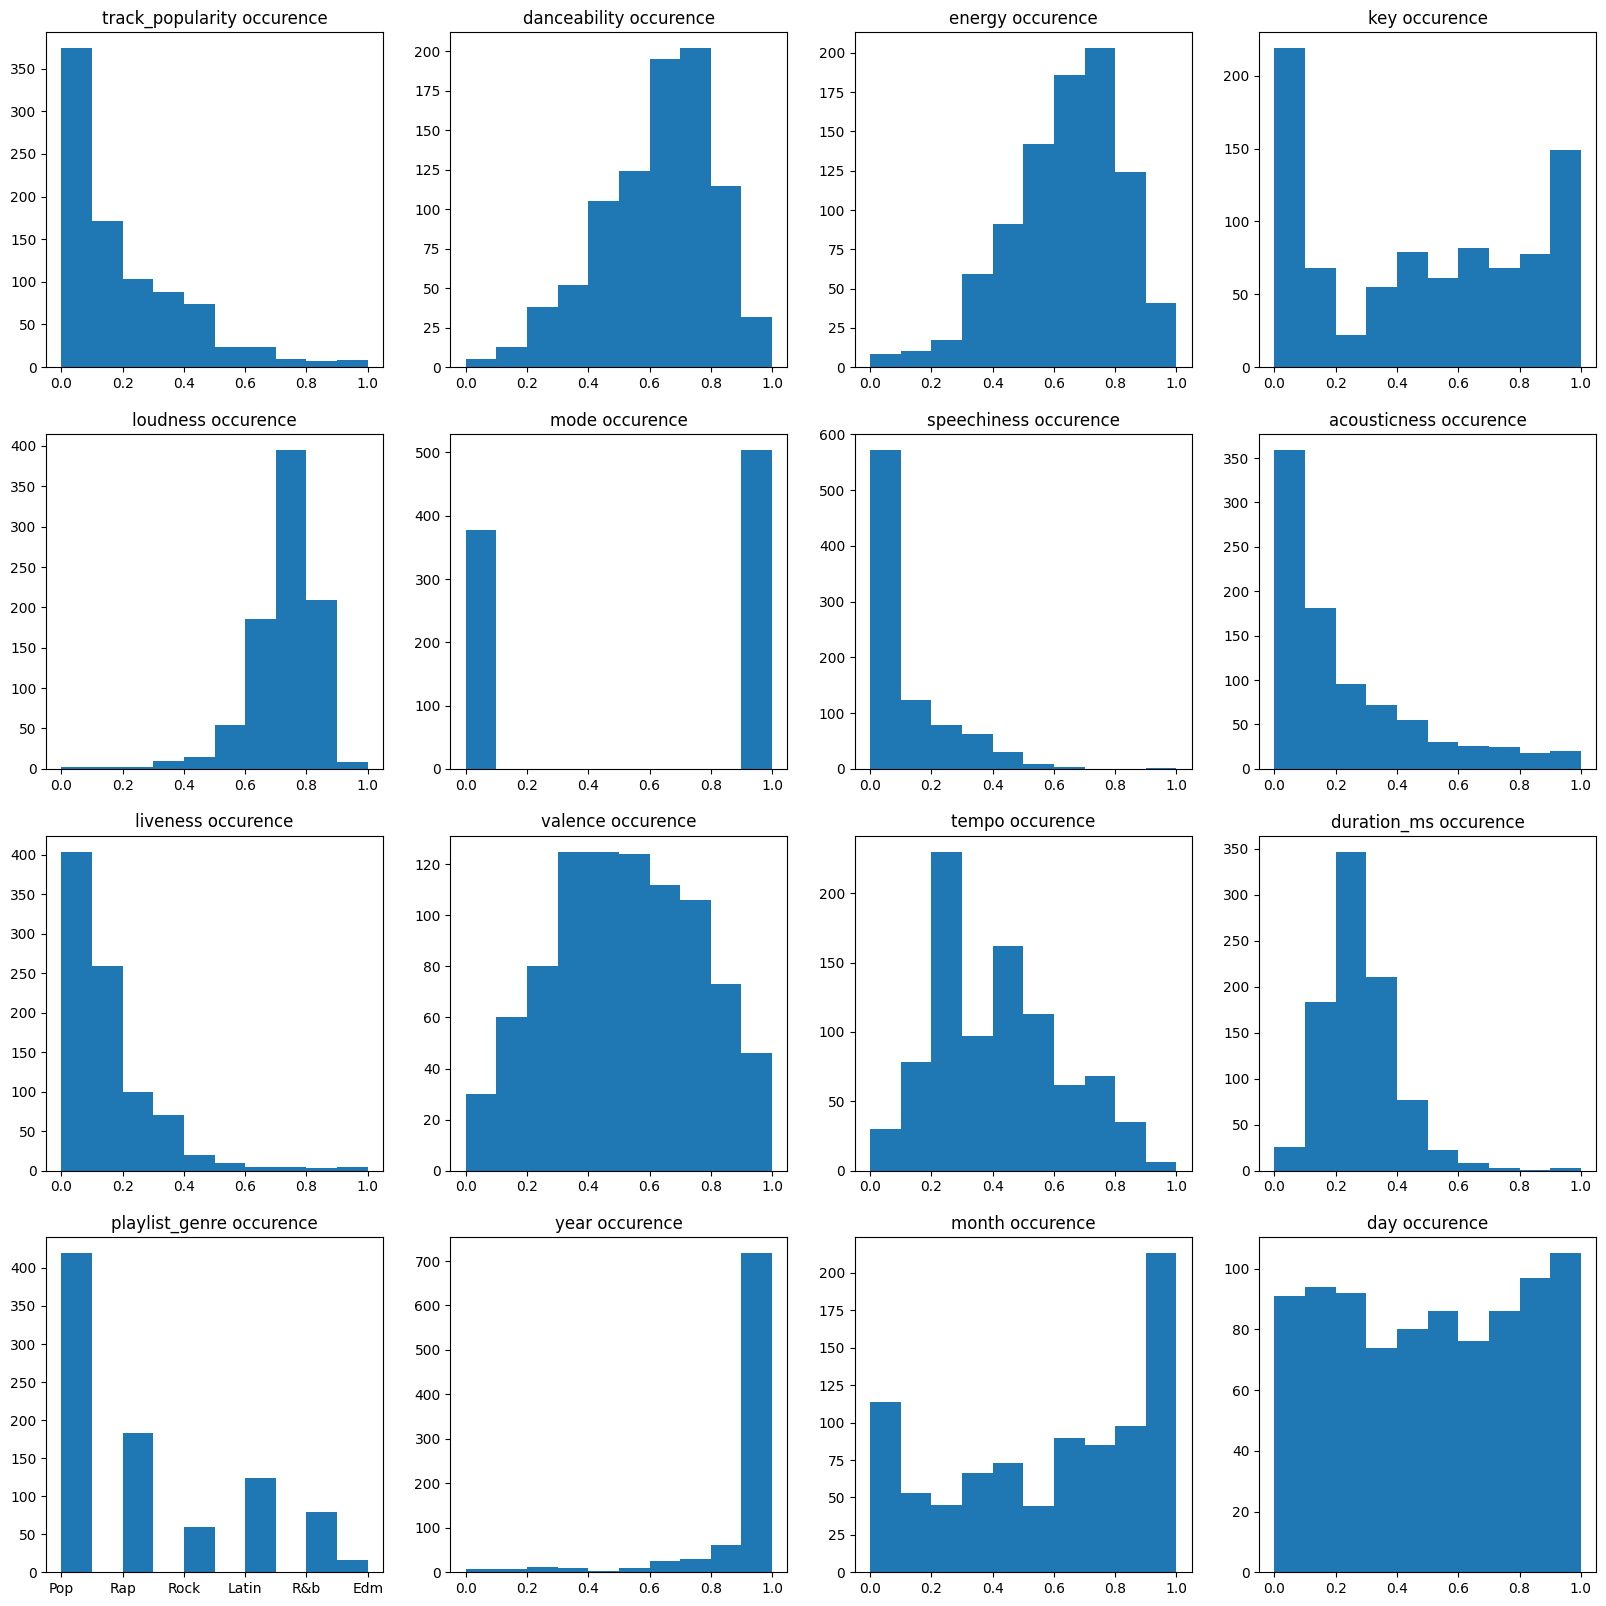

In [12]:
fig, ax = plt.subplots(4,4)
fig.set_size_inches(20, 20)
attributes = ['track_popularity', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
              'acousticness', 'liveness', 'valence', 'tempo', 'duration_ms', 'playlist_genre', 'year', 'month', 'day']
for i in range(0, 4):
  for j in range(0,4):
    ax[i][j].hist(df_not_null[attributes[i*4+j]])
    ax[i][j].set_title(f"{attributes[i*4+j]} occurence")

As we see, some attributes have small standard deviation and are not good for clustering, so we will choose: key, mode and genre as they are the best for clustering

As we skip month, day and year, we can work on full dataframe

In [13]:
df_scaled = df_dummies
df_scaled['duration_ms'] = scaler.fit_transform(df_scaled[['duration_ms']])
df_scaled['year'] = scaler.fit_transform(df_scaled[['year']])
df_scaled['month'] = scaler.fit_transform(df_scaled[['month']])
df_scaled['day'] = scaler.fit_transform(df_scaled[['day']])
df_scaled

,Unnamed: 0,track_id,track_name,track_artist,track_popularity,track_album_release_date,danceability,energy,key,loudness,...,year,month,day,playlist_genre_Edm,playlist_genre_Latin,playlist_genre_Pop,playlist_genre_R&b,playlist_genre_Rap,playlist_genre_Rock,playlist_genre
0,0,6oJ6le65B3SEqPwMRNXWjY,higher love,Kygo,0.500000,2019-06-28,0.632680,0.667346,0.727273,0.680129,...,0.981818,0.454545,0.900000,False,False,True,False,False,False,Pop
1,1,3yNZ5r3LKfdmjoS3gkhUCT,bad guy (with justin bieber),Billieeilish,0.318182,2019-07-11,0.602614,0.425904,0.000000,0.504094,...,0.981818,0.545455,0.333333,False,False,True,False,False,False,Pop
2,2,0qc4QlcCxVTGyShurEv1UU,post malone (feat. rani),Samfeldt,0.318182,2019-05-24,0.498039,0.628716,0.636364,0.821136,...,0.981818,0.363636,0.766667,False,False,True,False,False,False,Pop
3,3,4PkIDTPGedm0enzdvilLNd,sixteen,Elliegoulding,0.227273,2019-04-12,0.601307,0.799335,0.727273,0.753612,...,0.981818,0.272727,0.366667,False,False,True,False,False,False,Pop
4,4,5PYQUBXc7NYeI1obMKSJK0,never really over,Katyperry,0.409091,2019-05-31,0.733333,0.886254,0.727273,0.781608,...,0.981818,0.363636,1.000000,False,False,True,False,False,False,Pop
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
895,895,4gDvg62vG96w0qJaF6wzcd,a culpa é do meu grau (feat. zé neto & cristia...,Diego&victorhugo,0.090909,2019-03-22,0.435294,0.879815,0.545455,0.842229,...,0.981818,0.181818,0.700000,True,False,False,False,False,False,Edm
896,896,1uryupl9hqVZYurJwH4G9k,3 batidas - ao vivo,Guilherme&benuto,0.272727,2019-08-16,0.448366,0.700612,0.727273,0.754041,...,0.981818,0.636364,0.500000,True,False,False,False,False,False,Edm
897,897,2meEiZKWkiN28gITzFwQo5,into you,Arianagrande,0.136364,2016-05-20,0.541176,0.727439,0.818182,0.731961,...,0.927273,0.363636,0.633333,True,False,False,False,False,False,Edm
898,898,1ZLrDPgR7mvuTco3rQK8Pk,way back home (feat. conor maynard) - sam feld...,Shaun,0.045455,2018-12-21,0.690196,0.741389,0.909091,0.780493,...,0.963636,1.000000,0.666667,True,False,False,False,False,False,Edm


## Correlations


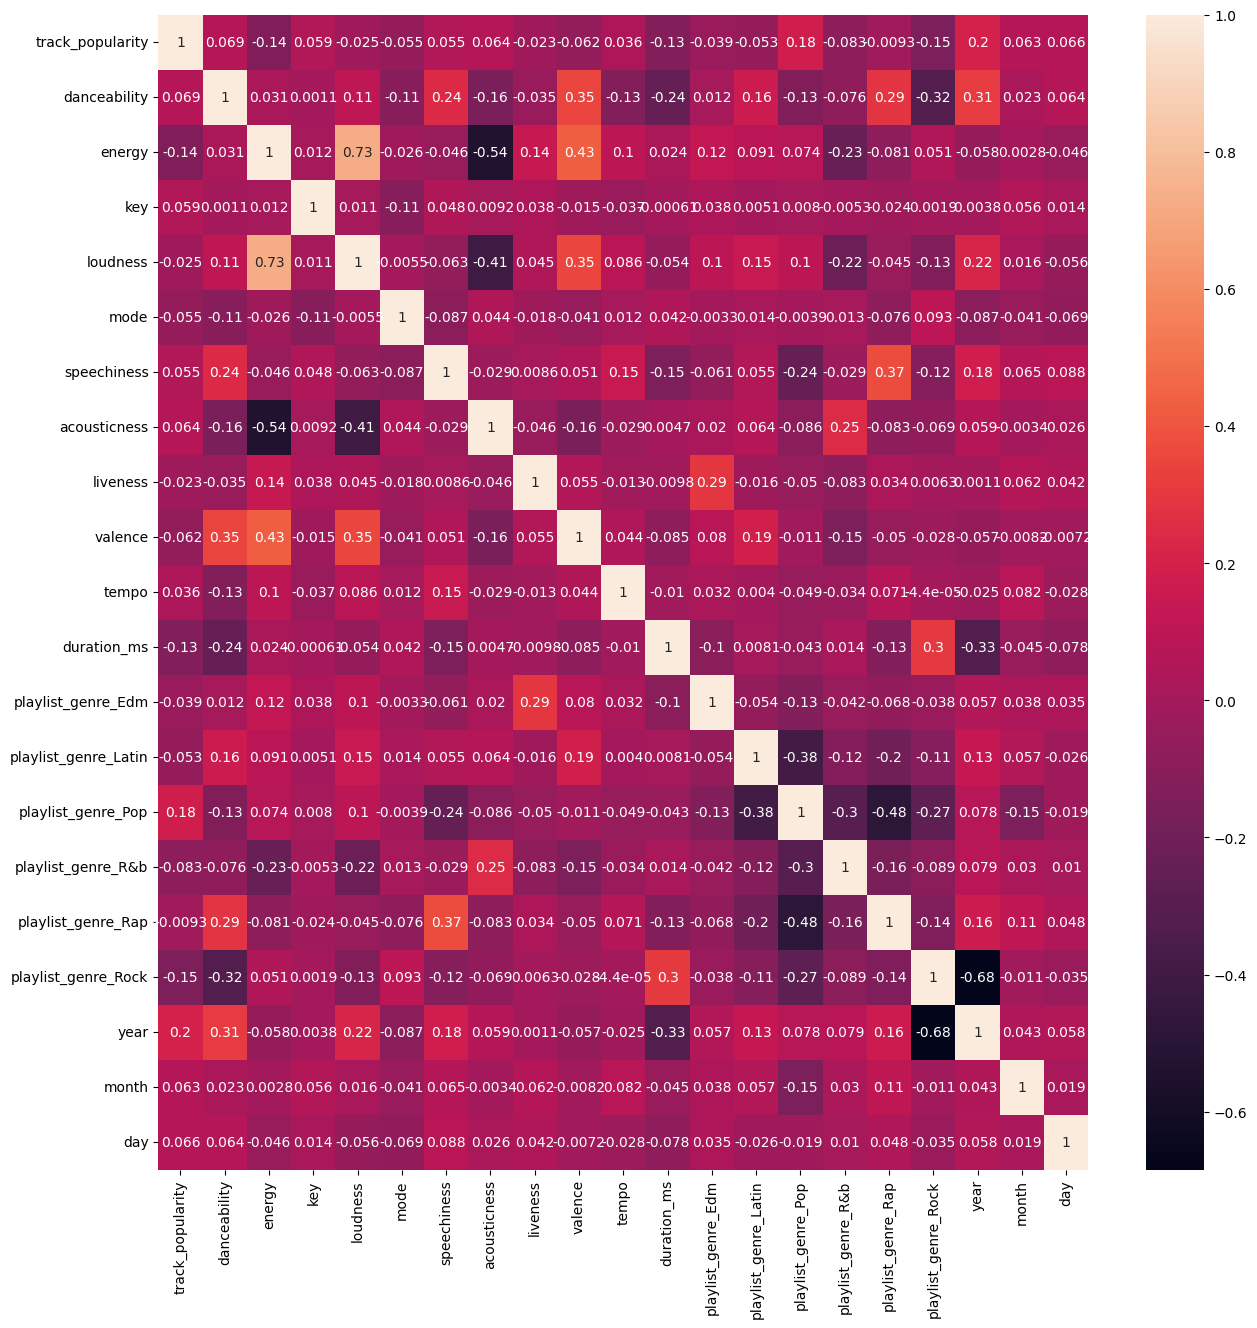

In [14]:
df_corr = df_dummies[['track_popularity', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
              'acousticness', 'liveness', 'valence', 'tempo', 'duration_ms', 'playlist_genre_Edm',
                      'playlist_genre_Latin',	'playlist_genre_Pop',	'playlist_genre_R&b',
                      'playlist_genre_Rap',	'playlist_genre_Rock', 'year', 'month', 'day']]
plt.figure(figsize=(15, 15))
sns.heatmap(df_corr.corr(), annot=True)
plt.show()

## Comparisions

As we see, key and mode does not correlate much with other variables, let's plot maps of those variables and key / mode

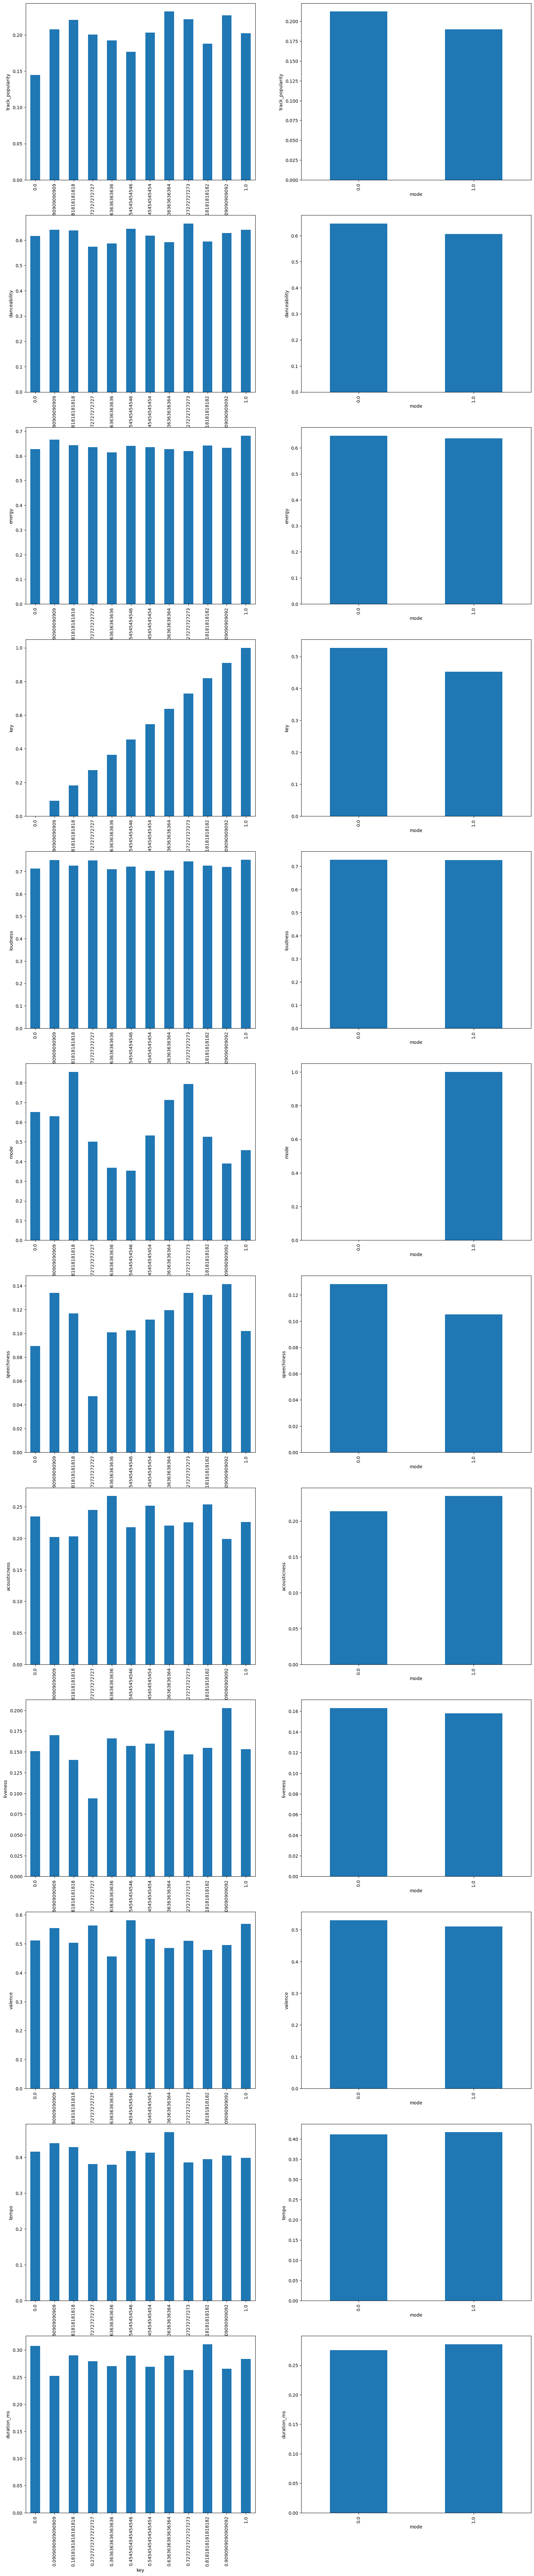

In [15]:
km = ['key', 'mode']
other = ['track_popularity', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
              'acousticness', 'liveness', 'valence', 'tempo', 'duration_ms']
fig, ax= plt.subplots(12, 2, figsize=(20, 100))
for row, i in enumerate(km):
  for col, j in enumerate(other):
    grouped = df_corr.groupby(i)[j].mean()
    ax[col][row] = grouped.plot.bar(ax=ax[col][row])
    ax[col][row].set_xlabel(f"{i}")
    ax[col][row].set_ylabel(f"{j}")

Let's plot the avarage of variables which correlate with some genres for each genre

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

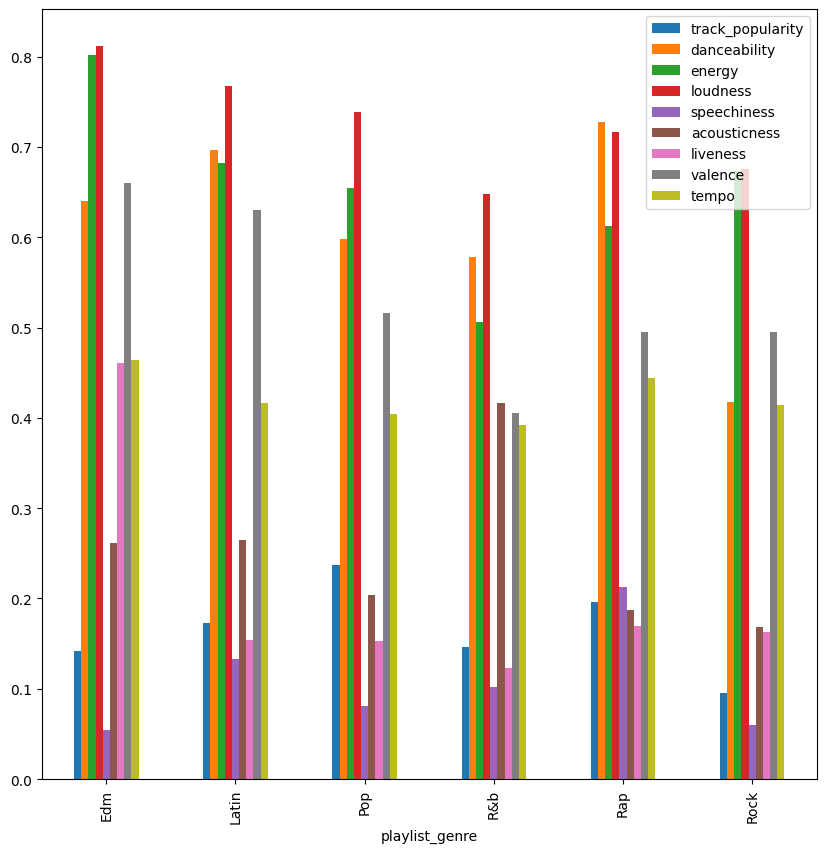

In [16]:
corr_no_dummy = df[['track_popularity', 'danceability', 'energy', 'loudness', 'speechiness',
              'acousticness', 'liveness', 'valence', 'tempo',
                      'playlist_genre']]
df_mean = corr_no_dummy.groupby('playlist_genre').mean()
df_mean.plot.bar(figsize=(10, 10))
plt

Let's see how variables changed through the year

In [17]:
def by_year_and_genre(variable):
  df_year_pop = df[['year','playlist_genre', variable]]
  df_year_pop = df_year_pop.groupby(['playlist_genre', 'year']).mean()
  genres = [('Edm', 'blue'), ('Latin', 'yellow'), ('Pop', 'pink'), ('R&b', 'green'), ('Rap', 'black'), ('Rock', 'red')]
  for i in genres:
    plt.figure(figsize=(17, 5))
    plt.plot(df_year_pop.loc[i[0]].index, df_year_pop.loc[i[0]][variable], color=i[1])
    plt.title(f"{i[0]} genre {variable} through the years")
    plt.show()

In [18]:
def by_year(variable):
  df_year_pop = df[['year', variable]]
  df_year_pop = df_year_pop.groupby(['year']).mean()
  plt.figure(figsize=(20, 10))
  plt.plot(df_year_pop.index, df_year_pop[variable])
  plt.title(f"{variable} through the years")
  plt.show()

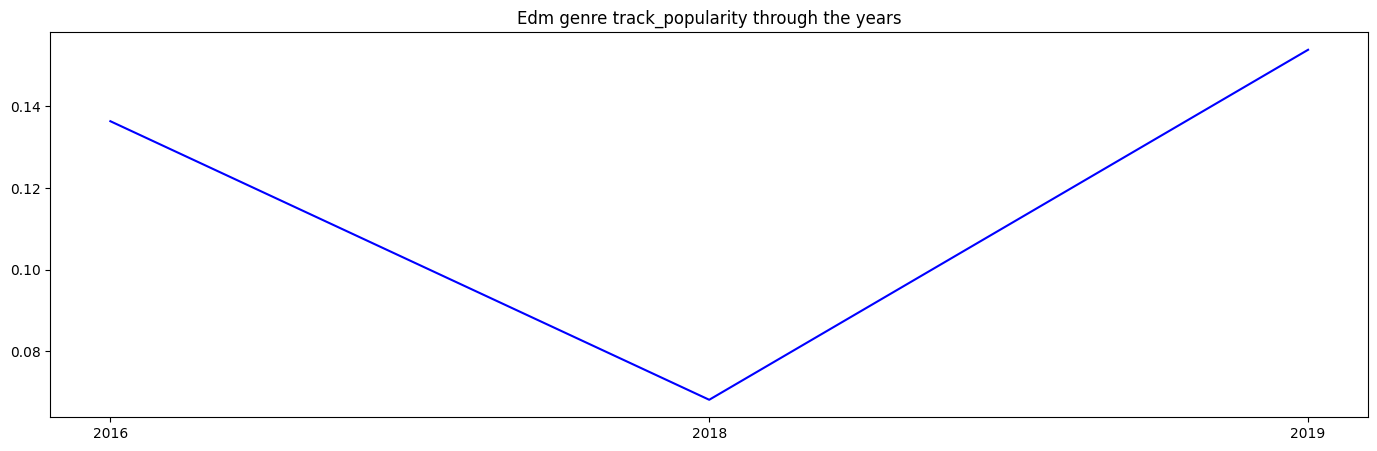

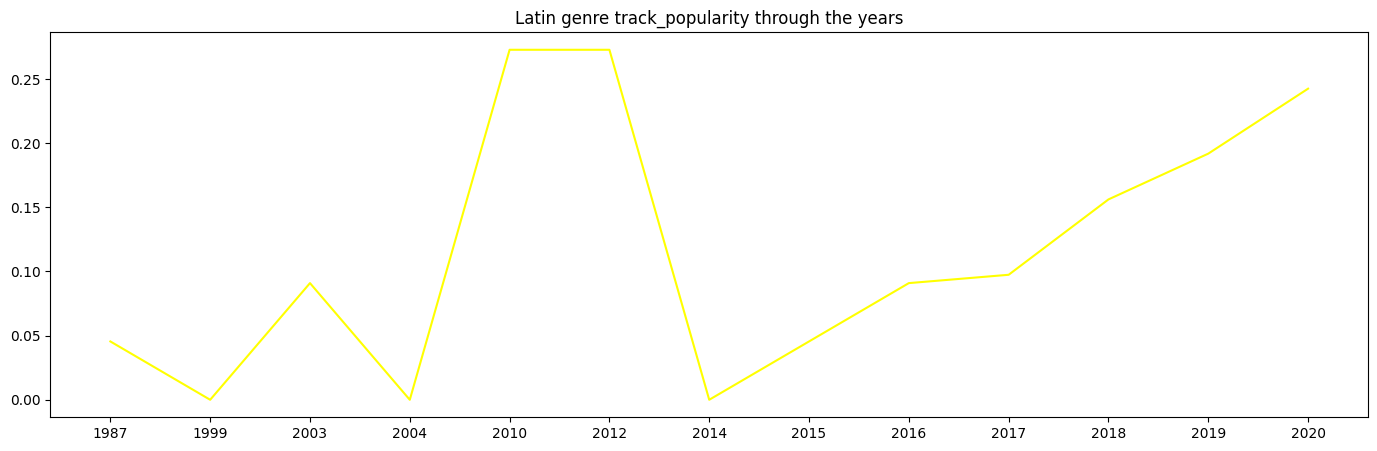

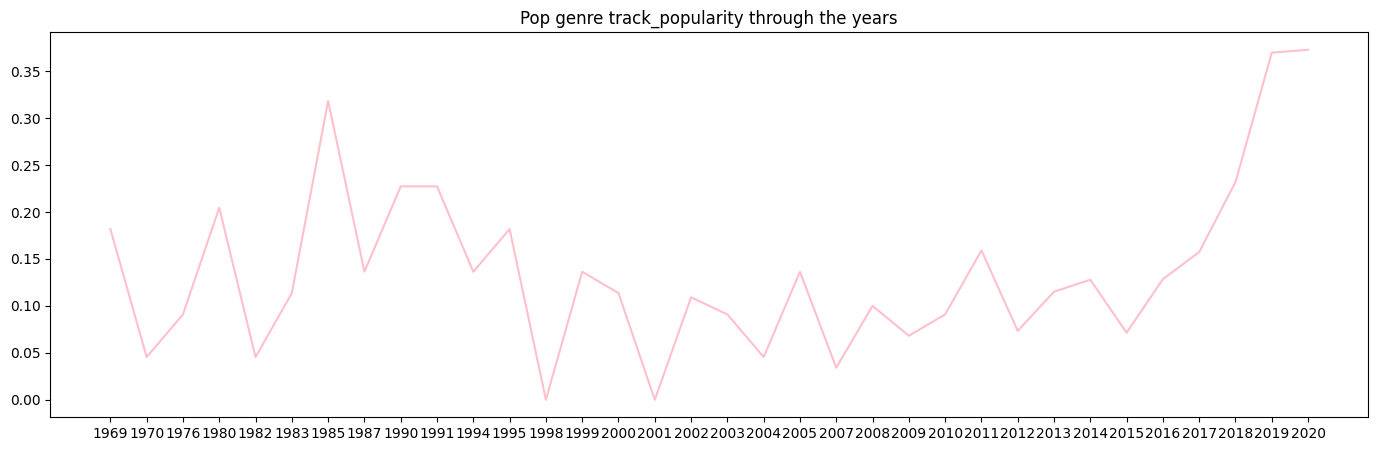

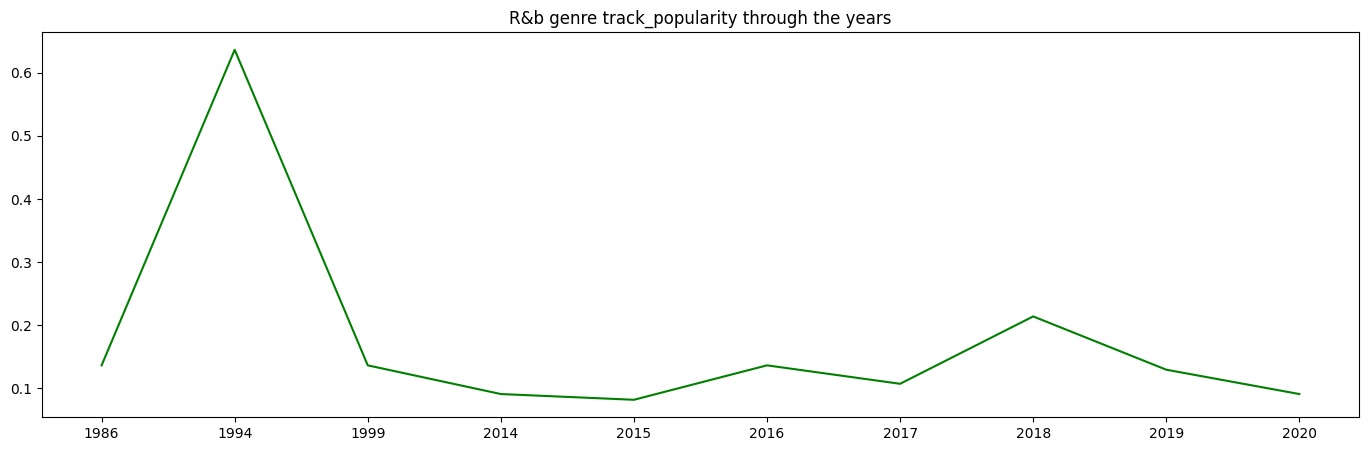

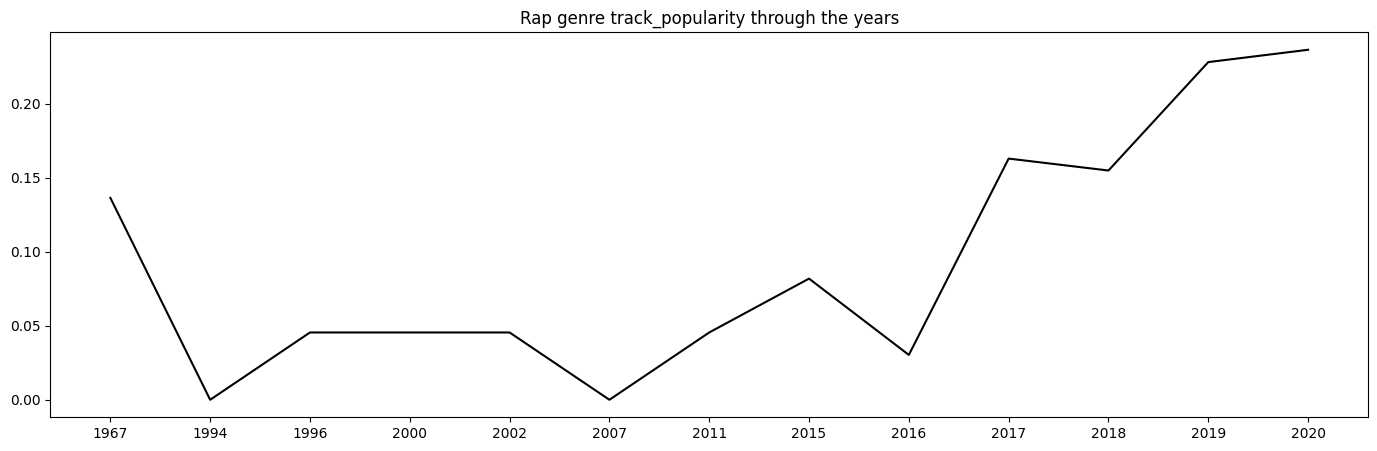

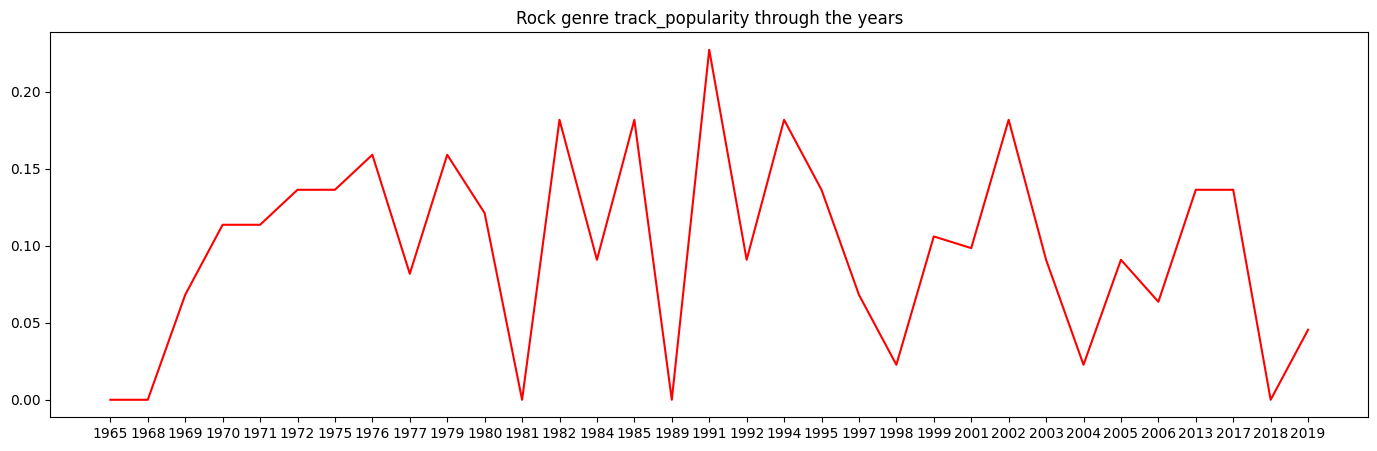

In [19]:
by_year_and_genre('track_popularity')

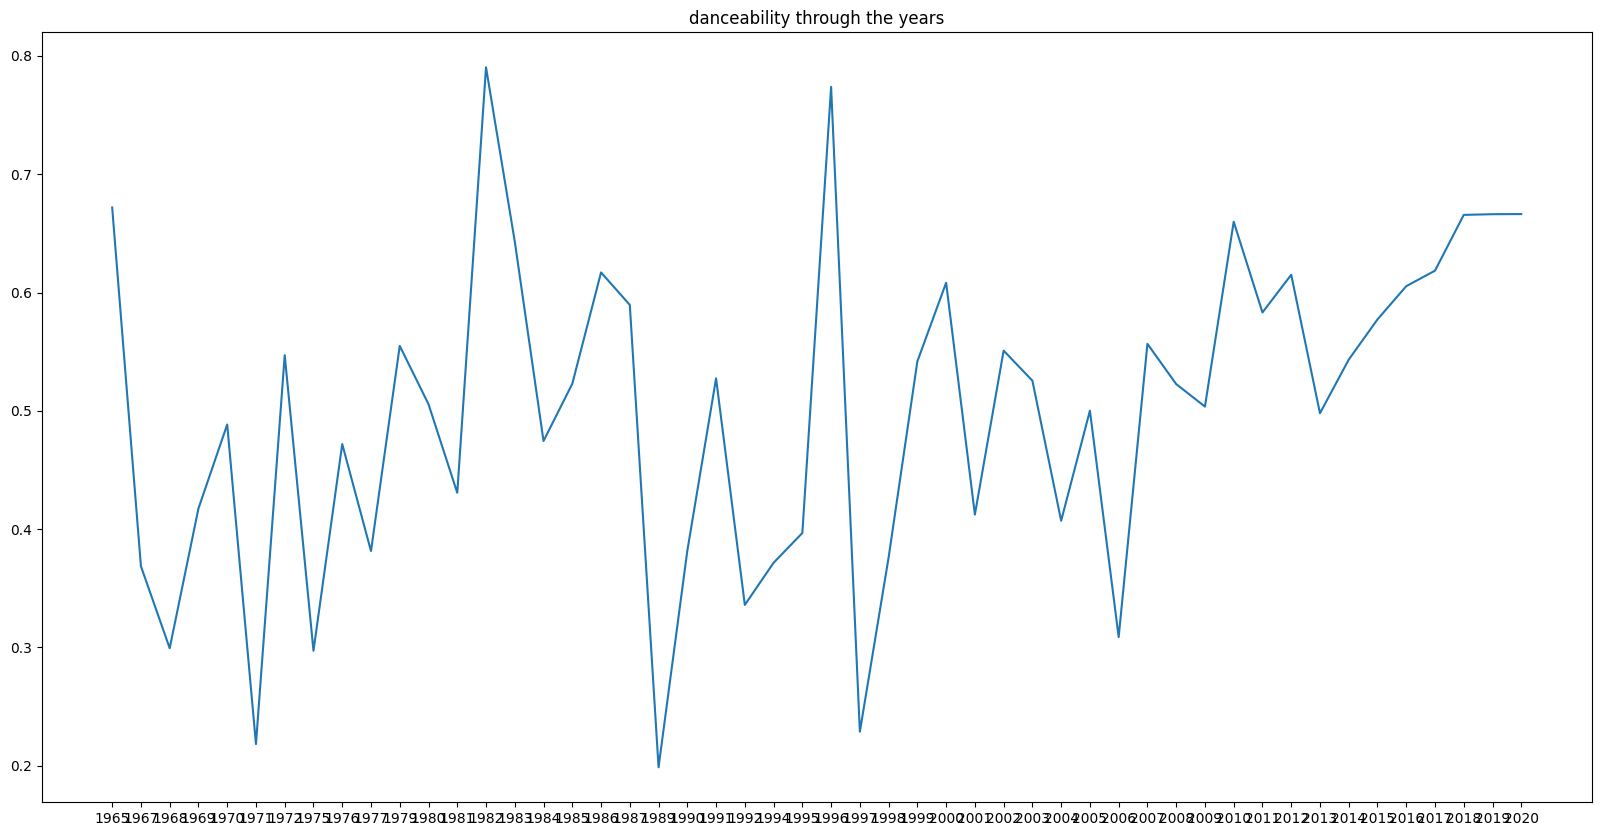

In [20]:
by_year('danceability')

As we see, month correlates with pop genre

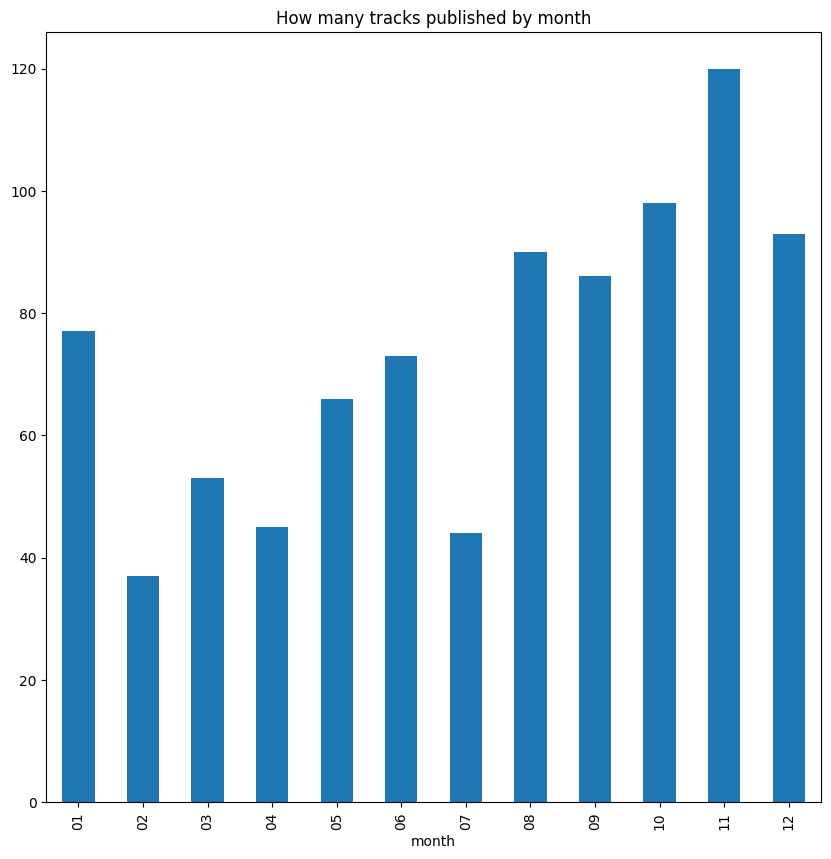

In [21]:
df['month'].value_counts().sort_index().plot.bar(figsize=(10, 10))
plt.title("How many tracks published by month")
plt.show()

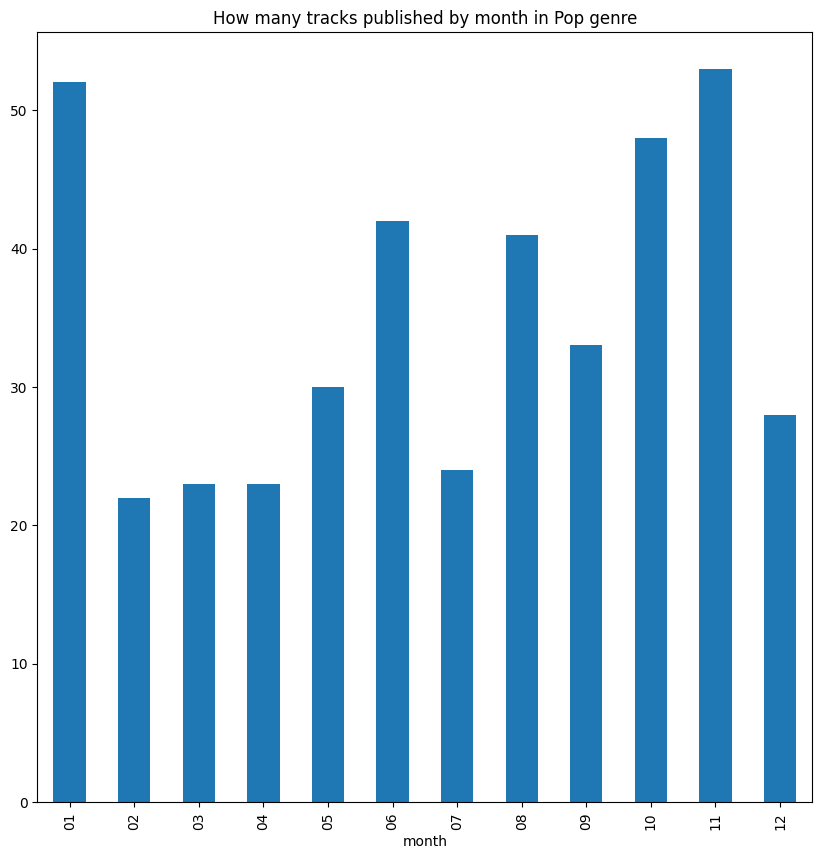

In [22]:
df[df['playlist_genre'] == 'Pop']['month'].value_counts().sort_index().plot.bar(figsize=(10, 10))
plt.title("How many tracks published by month in Pop genre")
plt.show()

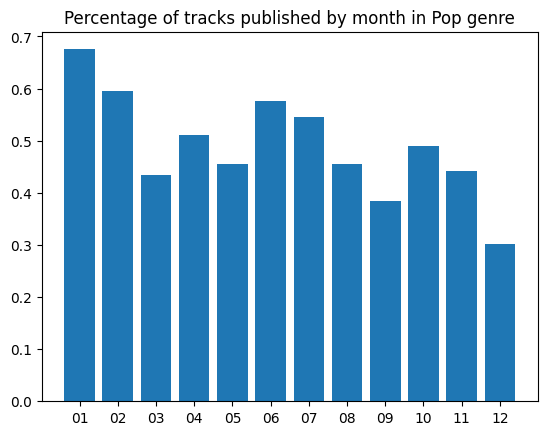

Avarage percentage is 0.47555555555555556


In [23]:
month_percentage = pd.DataFrame()
month_percentage['Pop'] = df[df['playlist_genre'] == 'Pop']['month'].value_counts()
month_percentage['all'] = df['month'].value_counts()
month_percentage = month_percentage.sort_values('month')
month_percentage['percentage'] = month_percentage['Pop'] / month_percentage['all']
plt.bar(month_percentage.index, month_percentage['percentage'])
plt.title("Percentage of tracks published by month in Pop genre")
plt.show()
print(f"Avarage percentage is {df[df['playlist_genre'] == 'Pop'].shape[0] / df.shape[0]}")

Text(0.5, 1.0, 'Avarage songs duration through the years')

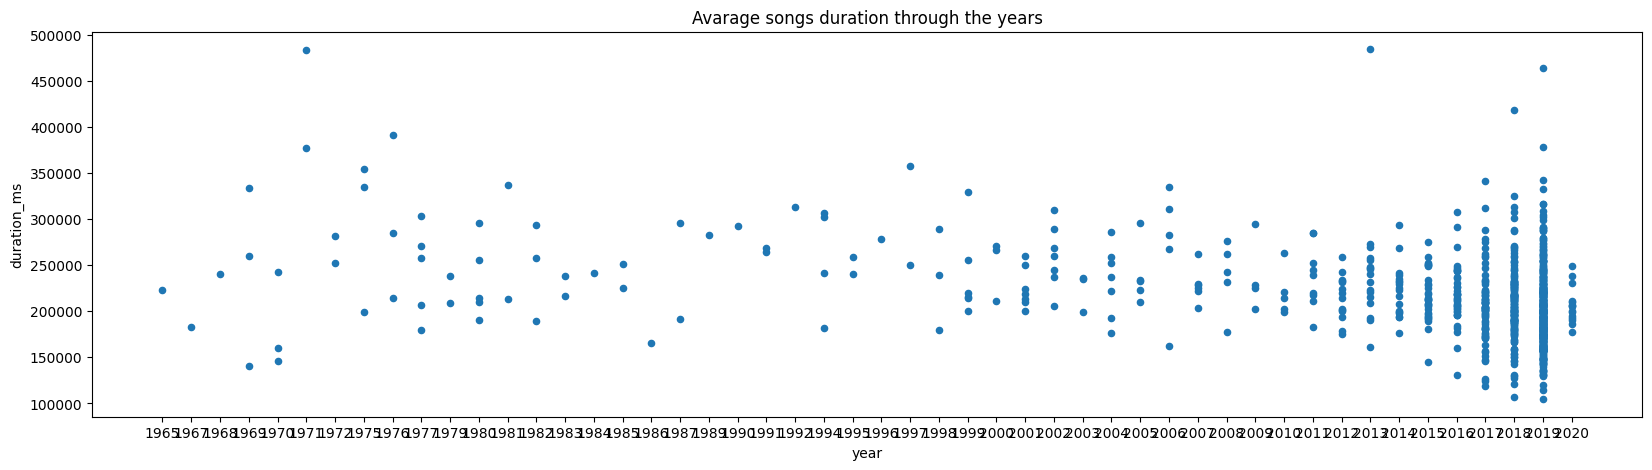

In [24]:
comparision = df[['year', 'duration_ms']]
comparision.sort_values('year').plot.scatter('year', 'duration_ms', figsize=(20, 5))
plt.title("Avarage songs duration through the years")

Text(0.5, 1.0, 'Songs loudness through the years')

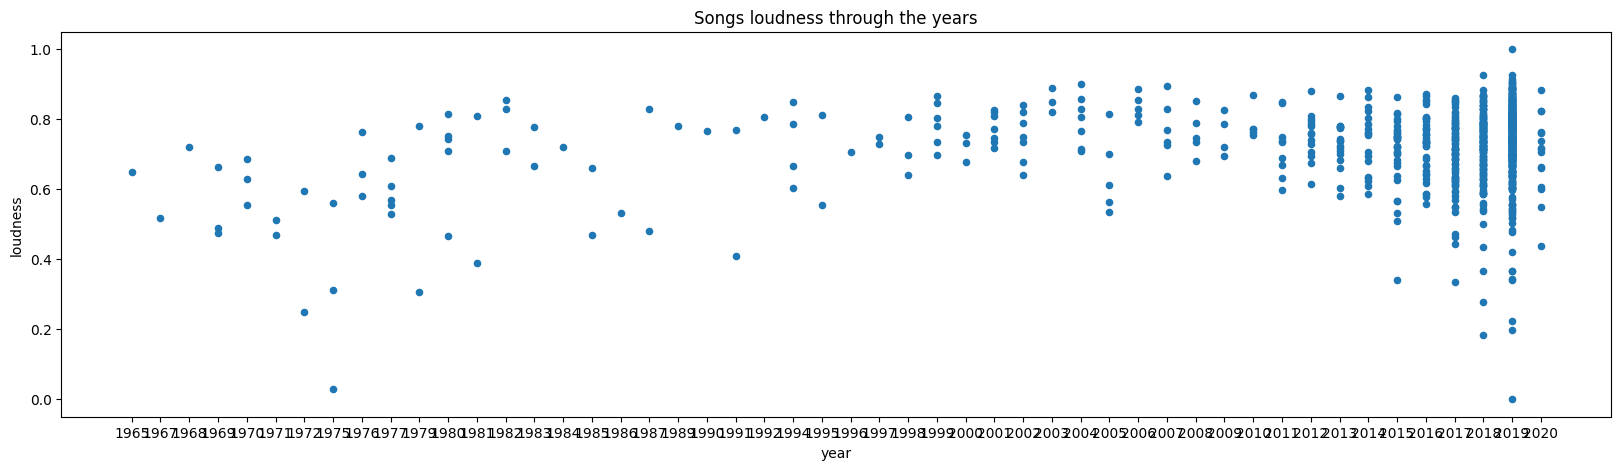

In [25]:
comparision = df[['year', 'loudness']]
comparision.sort_values('year').plot.scatter('year', 'loudness', figsize=(20, 5))
plt.title("Songs loudness through the years")

Text(0.5, 1.0, 'Songs danceability through the years')

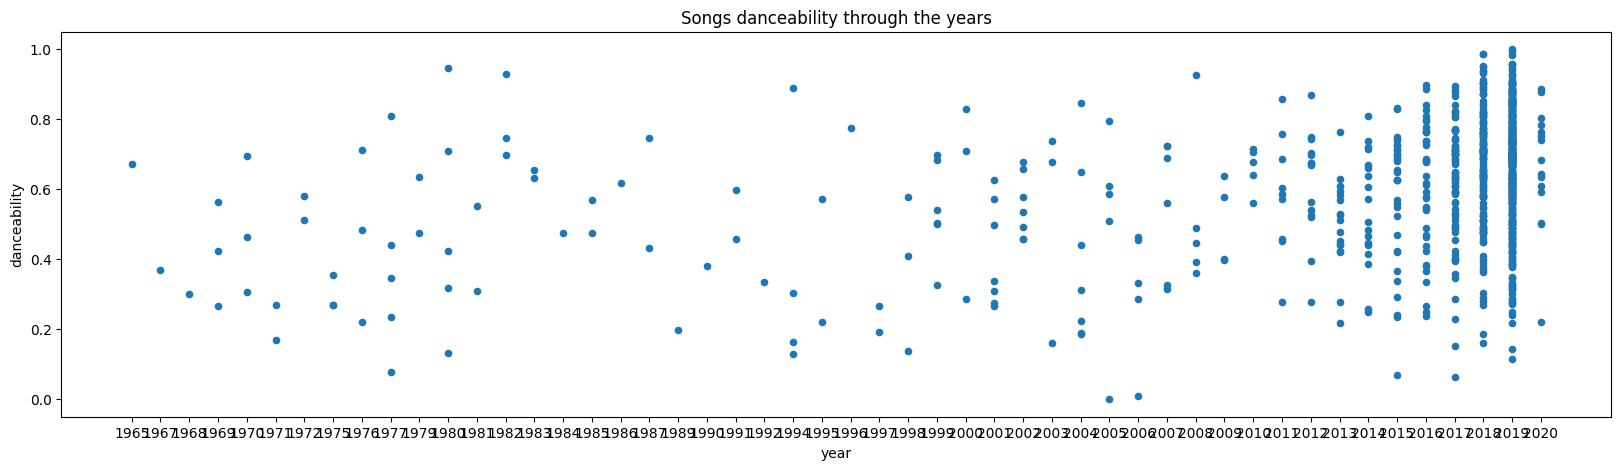

In [26]:
comparision = df[['year', 'danceability']]
comparision.sort_values('year').plot.scatter('year', 'danceability', figsize=(20, 5))
plt.title("Songs danceability through the years")

As we see, some correlations must be the results of the fact that there are more songs from recent years in the database

# Clustering and retrieval

## Retrieval

In [27]:
!pip install scikit-learn

In [28]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.metrics.pairwise import cosine_distances
from sklearn.metrics.pairwise import pairwise_distances

We need to add author's name and track's name to the lyrics, as we want to include the authors in the distance matrix. We want the author to be counted as one word because else songs whose authors are Rob Smith and Anna Smith would be considered more similar

In [29]:
df_scaled['to_vectorize'] = df_scaled['track_artist'] + " "+ df_scaled['track_name'] + " " + df_scaled['tags']
df_scaled['to_vectorize']

,to_vectorize
0,Kygo higher love bring higher love love bring ...
1,Billieeilish bad guy (with justin bieber) yeah...
2,Samfeldt post malone (feat. rani) one drink go...
3,Elliegoulding sixteen sixteen sixteen remember...
4,Katyperry never really over im losing self con...
...,...
895,Diego&victorhugo a culpa é do meu grau (feat. ...
896,Guilherme&benuto 3 batidas - ao vivo pensa num...
897,Arianagrande into you im barely breathe wan na...
898,Shaun way back home (feat. conor maynard) - sa...


Now let's extract words tf-idf vectors

In [30]:
x = df_scaled['to_vectorize']
vectorizer = CountVectorizer(token_pattern=r"(?u)\b[^\d\W]+\b")
WCMatrix = vectorizer.fit_transform(x)
TFIDFMatrix = TfidfTransformer().fit_transform(WCMatrix)
TFIDFMatrix

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 99849 stored elements and shape (900, 19129)>

Now let's prepare the lyrics distance matrix. It will show the distances between each song's lyrics

In [31]:
lyrics_distance = cosine_distances(TFIDFMatrix)
print(f"Size: {len(lyrics_distance)} x {len(lyrics_distance[0])}")

Size: 900 x 900


This function will show the lyrics similiarites to a given song

In [32]:
def similars_to(track_name, matrix, df_scaled):
  song_index = df_scaled[df_scaled['track_name'] == track_name].index[0]
  distances = matrix[song_index]
  df_distances = df
  df_distances['distance'] = distances
  return df_distances.sort_values('distance')

In [33]:
similars_to('we are the champions - remastered 2011', lyrics_distance, df_scaled)

,Unnamed: 0,track_id,track_name,track_artist,track_popularity,track_album_release_date,playlist_genre,danceability,energy,key,...,tags_tokenized,doc_vector,combined_vector,cluster,image_url,spotify_url,year,month,day,distance
613,613,1lCRw5FEZ1gPDNPzy1K4zW,we are the champions - remastered 2011,Queen,0.000000,1977-10-28,Rock,0.077124,0.432343,0.909091,...,"['ive', 'paid', 'dues', 'time', 'time', 'ive',...",[-1.75410479e-01 1.83482334e-01 1.95978343e-...,[-1.75410479e-01 1.83482334e-01 1.95978343e-...,3,https://i.scdn.co/image/ab67616d0000b2731f7077...,https://open.spotify.com/track/1lCRw5FEZ1gPDNP...,1977,10,28,0.000000
679,679,61mWefnWQOLf90gepjOCb3,duality,Slipknot,0.000000,2004,Rock,0.189542,0.993562,0.363636,...,"['push', 'fingers', 'eyes', 'thing', 'slowly',...",[-5.54844402e-02 1.87931195e-01 2.35906452e-...,[-5.54844402e-02 1.87931195e-01 2.35906452e-...,2,https://i.scdn.co/image/ab67616d0000b2736b3463...,https://open.spotify.com/track/61mWefnWQOLf90g...,2004,None,None,0.884999
59,59,2tpWsVSb9UEmDRxAl1zhX1,counting stars,Onerepublic,0.181818,2013-01-01,Pop,0.594771,0.696319,0.090909,...,"['lately', 'ive', 'ive', 'losing', 'sleep', 'd...",[-1.17594123e-01 3.04478109e-01 1.97015405e-...,[-1.17594123e-01 3.04478109e-01 1.97015405e-...,2,https://i.scdn.co/image/ab67616d0000b2739e2f95...,https://open.spotify.com/track/2tpWsVSb9UEmDRx...,2013,01,01,0.902717
330,330,7wMq5n8mYSKlQIGECKUgTX,hall of fame,Thescript,0.090909,2012-09-07,Pop,0.277124,0.876596,0.909091,...,"['yeah', 'could', 'greatest', 'best', 'king', ...",[-0.04222161 0.11155049 0.24951792 0.108176...,[-0.04222161 0.11155049 0.24951792 0.108176...,3,https://i.scdn.co/image/ab67616d0000b2732e3049...,https://open.spotify.com/track/7wMq5n8mYSKlQIG...,2012,09,07,0.903491
583,583,7m9OqQk4RVRkw9JJdeAw96,jocelyn flores,Xxxtentacion,0.454545,2017-08-25,Rap,0.866667,0.359373,0.000000,...,"['know', 'well', 'well', 'mean', 'anything', '...",[-2.29584739e-01 1.45942241e-01 3.45083803e-...,[-2.29584739e-01 1.45942241e-01 3.45083803e-...,2,https://i.scdn.co/image/ab67616d0000b273203c89...,https://open.spotify.com/track/7m9OqQk4RVRkw9J...,2017,08,25,0.909334
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104,104,0gcOnIUKIG6JF56iFUfE0p,bonita,Juanes,0.090909,2019-09-06,Pop,0.700654,0.885181,0.000000,...,"['quera', 'enamorarme', 'fui', 'de', 'fiesta',...",[-0.3511072 0.38074875 0.14206451 0.333678...,[-0.35110721 0.38074875 0.14206451 0.333678...,1,https://i.scdn.co/image/ab67616d0000b27368d515...,https://open.spotify.com/track/0gcOnIUKIG6JF56...,2019,09,06,1.000000
120,120,29MOOOmMRPeWyPwKQFoF5t,i feel love,Samsmith,0.090909,2019-11-01,Pop,0.666667,0.699539,0.000000,...,"['good', 'good', 'good', 'falling', 'free', 'f...",[-0.33187535 0.368593 0.49047124 0.384353...,[-0.33187535 0.36859301 0.49047124 0.384353...,1,https://i.scdn.co/image/ab67616d0000b27359c9a7...,https://open.spotify.com/track/29MOOOmMRPeWyPw...,2019,11,01,1.000000
88,88,2ksOAxtIxY8yElEWw8RhgK,china,Anuelaa,0.772727,2019-07-19,Pop,0.754248,0.806846,0.636364,...,"['mi', 'mujer', 'estaba', 'llamando', 'nananan...",[-0.36091536 0.37385696 0.08407214 0.265099...,[-0.36091536 0.37385696 0.08407214 0.265099...,3,https://i.scdn.co/image/ab67616d0000b2735fa6dc...,https://open.spotify.com/track/2ksOAxtIxY8yElE...,2019,07,19,1.000000
73,73,430efk5Jc5wGay4EWP4snS,baianá,Bakermat,0.000000,2019-11-08,Pop,0.376471,0.749973,0.181818,...,"['mais', 'outra', 'vez', 'apresentar', 'meu', ...",[-1.16716750e-01 3.58838320e-01 1.36166871e-...,[-1.16716750e-01 3.58838320e-01 1.36166871e-...,2,https://i.scdn.co/image/ab67616d0000b27379c209...,https://open.spotify.com/track/430efk5Jc5wGay4...,2019,11,08,1.000000


Now let's make a distance matrix on other attributes

In [34]:
attributes = df_scaled[['key', 'mode', 'playlist_genre_Edm',
                      'playlist_genre_Latin',	'playlist_genre_Pop',	'playlist_genre_R&b',
                      'playlist_genre_Rap',	'playlist_genre_Rock']]

In [35]:
attr_matrix = pairwise_distances(attributes)
print(f"Size: {len(attr_matrix)} x {len(attr_matrix[0])}")

Size: 900 x 900


Let's now check how this works for some song

In [36]:
similars_to('we are the champions - remastered 2011', attr_matrix, df_scaled)

,Unnamed: 0,track_id,track_name,track_artist,track_popularity,track_album_release_date,playlist_genre,danceability,energy,key,...,tags_tokenized,doc_vector,combined_vector,cluster,image_url,spotify_url,year,month,day,distance
631,631,2RlgNHKcydI9sayD2Df2xp,mr. blue sky,Electriclightorchestra,0.136364,1977,Rock,0.233987,0.302500,0.909091,...,"['morning', 'todays', 'forecast', 'calls', 'bl...",[-0.11061782 0.21816505 0.16572921 0.152150...,[-0.11061782 0.21816505 0.16572921 0.152150...,3,https://i.scdn.co/image/ab67616d0000b2738c4e95...,https://open.spotify.com/track/2RlgNHKcydI9say...,1977,None,None,0.000000
640,640,3gdewACMIVMEWVbyb8O9sY,"rocket man (i think it's going to be a long, l...",Eltonjohn,0.227273,1972-05-19,Rock,0.512418,0.510677,0.909091,...,"['packed', 'bags', 'last', 'night', 'preflight...",[-0.22240067 0.10955543 0.3323467 0.250385...,[-0.22240067 0.10955543 0.33234671 0.250385...,3,https://i.scdn.co/image/ab67616d0000b273300900...,https://open.spotify.com/track/3gdewACMIVMEWVb...,1972,05,19,0.000000
613,613,1lCRw5FEZ1gPDNPzy1K4zW,we are the champions - remastered 2011,Queen,0.000000,1977-10-28,Rock,0.077124,0.432343,0.909091,...,"['ive', 'paid', 'dues', 'time', 'time', 'ive',...",[-1.75410479e-01 1.83482334e-01 1.95978343e-...,[-1.75410479e-01 1.83482334e-01 1.95978343e-...,3,https://i.scdn.co/image/ab67616d0000b2731f7077...,https://open.spotify.com/track/1lCRw5FEZ1gPDNP...,1977,10,28,0.000000
644,644,0gmbgwZ8iqyMPmXefof8Yf,how you remind me,Nickelback,0.090909,2001-09-11,Rock,0.309804,0.759631,0.909091,...,"['never', 'made', 'wise', 'man', 'couldnt', 'c...",[-0.33165956 0.20192628 0.31684607 0.263485...,[-3.31659555e-01 2.01926276e-01 3.16846073e-...,3,https://i.scdn.co/image/ab67616d0000b273699a42...,https://open.spotify.com/track/0gmbgwZ8iqyMPmX...,2001,09,11,0.000000
659,659,3ZOEytgrvLwQaqXreDs2Jx,can't stop,Redhotchilipeppers,0.181818,2002-07-09,Rock,0.534641,0.946346,0.818182,...,"['cant', 'stop', 'addicted', 'shindig', 'chop'...",[-0.21019174 0.14912345 0.24712825 0.218040...,[-2.10191742e-01 1.49123445e-01 2.47128248e-...,3,https://i.scdn.co/image/ab67616d0000b273de1af2...,https://open.spotify.com/track/3ZOEytgrvLwQaqX...,2002,07,09,0.090909
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
814,814,3Yh9lZcWyKrK9GjbhuS0hR,good as hell,Lizzo,0.318182,2016-03-09,R&b,0.618301,0.925958,0.000000,...,"['hair', 'toss', 'check', 'nails', 'baby', 'fe...",[-0.17053789 0.17418183 0.41090018 0.107990...,[-0.17053789 0.17418183 0.41090018 0.107990...,2,https://i.scdn.co/image/ab67616d0000b273cb4af8...,https://open.spotify.com/track/3Yh9lZcWyKrK9Gj...,2016,03,09,1.956130
851,851,4Yxc55NX3tAXC2mHRAhtcW,"all i want - from ""high school musical: the mu...",Oliviarodrigo,0.318182,2019-11-27,R&b,0.218301,0.401223,0.000000,...,"['found', 'guy', 'told', 'star', 'held', 'door...",[-2.35673532e-01 2.12621942e-01 3.32589060e-...,[-2.35673532e-01 2.12621942e-01 3.32589060e-...,2,https://i.scdn.co/image/ab67616d0000b2736d38bb...,https://open.spotify.com/track/4Yxc55NX3tAXC2m...,2019,11,27,1.956130
856,856,3O8X1DE9btbzy4UH9cSX9a,borderline,Tameimpala,0.000000,2019-04-12,R&b,0.508497,0.701685,0.000000,...,"['ah', 'gone', 'little', 'far', 'gone', 'littl...",[-1.74073175e-01 1.51341692e-01 2.18856752e-...,[-1.74073175e-01 1.51341692e-01 2.18856752e-...,2,https://i.scdn.co/image/ab67616d0000b273b9fc7f...,https://open.spotify.com/track/3O8X1DE9btbzy4U...,2019,04,12,1.956130
550,550,7eBqSVxrzQZtK2mmgRG6lC,murder on my mind,Ynwmelly,0.409091,2018-08-03,Rap,0.718954,0.723146,0.000000,...,"['get', 'roll', 'ayy', 'im', 'studio', 'bro', ...",[-1.68910891e-01 -4.24284190e-02 3.11034530e-...,[-1.68910891e-01 -4.24284190e-02 3.11034530e-...,2,https://i.scdn.co/image/ab67616d0000b2730f5397...,https://open.spotify.com/track/7eBqSVxrzQZtK2m...,2018,08,03,1.956130


Now let's combine our distance matrices into one

In [37]:
lyrics_weight = 0.6
attributes_weight = 0.4
similarity_matrix = lyrics_distance * lyrics_weight + attr_matrix * attributes_weight

Let's test how it works for some songs

In [38]:
similars_to('another one bites the dust - remastered 2011', similarity_matrix, df_scaled).head(5)

,Unnamed: 0,track_id,track_name,track_artist,track_popularity,track_album_release_date,playlist_genre,danceability,energy,key,...,tags_tokenized,doc_vector,combined_vector,cluster,image_url,spotify_url,year,month,day,distance
629,629,5vdp5UmvTsnMEMESIF2Ym7,another one bites the dust - remastered 2011,Queen,0.272727,1980-06-27,Rock,0.946405,0.506385,0.454545,...,"['ooh', 'lets', 'go', 'steve', 'walks', 'waril...",[-1.17498726e-01 1.14733912e-01 3.51513237e-...,[-1.17498726e-01 1.14733912e-01 3.51513237e-...,0,https://i.scdn.co/image/ab67616d0000b273056e90...,https://open.spotify.com/track/5vdp5UmvTsnMEME...,1980,06,27,0.000000
658,658,5W8YXBz9MTIDyrpYaCg2Ky,last resort,Paparoach,0.136364,2001-04-25,Rock,0.496732,0.894839,0.363636,...,"['cut', 'life', 'pieces', 'last', 'resort', 's...",[-2.86687106e-01 1.21276945e-01 3.12670618e-...,[-2.86687106e-01 1.21276945e-01 3.12670618e-...,2,https://i.scdn.co/image/ab67616d0000b273985bf5...,https://open.spotify.com/track/5W8YXBz9MTIDyrp...,2001,04,25,0.620302
616,616,2zYzyRzz6pRmhPzyfMEC8s,highway to hell,Ac/dc,0.318182,1979-07-27,Rock,0.475817,0.919519,0.545455,...,"['livin', 'easy', 'lovin', 'free', 'season', '...",[-0.19858196 0.0260861 0.37695372 0.212360...,[-0.19858196 0.0260861 0.37695372 0.212360...,4,https://i.scdn.co/image/ab67616d0000b27351c02a...,https://open.spotify.com/track/2zYzyRzz6pRmhPz...,1979,07,27,0.626044
679,679,61mWefnWQOLf90gepjOCb3,duality,Slipknot,0.000000,2004,Rock,0.189542,0.993562,0.363636,...,"['push', 'fingers', 'eyes', 'thing', 'slowly',...",[-5.54844402e-02 1.87931195e-01 2.35906452e-...,[-5.54844402e-02 1.87931195e-01 2.35906452e-...,2,https://i.scdn.co/image/ab67616d0000b2736b3463...,https://open.spotify.com/track/61mWefnWQOLf90g...,2004,None,None,0.628817
663,663,0COqiPhxzoWICwFCS4eZcp,bring me to life,Evanescence,0.090909,2003-01-01,Rock,0.159477,0.951712,0.363636,...,"['see', 'eyes', 'like', 'open', 'doors', 'lead...",[-0.25853488 0.2183911 0.26621196 0.172446...,[-0.25853488 0.21839111 0.26621196 0.172446...,2,https://i.scdn.co/image/ab67616d0000b27325f49a...,https://open.spotify.com/track/0COqiPhxzoWICwF...,2003,01,01,0.629920


## Clustering

Let's try some methods of clustering and see how it classified our songs

### K-Means

In [39]:
from sklearn.cluster import KMeans

In [40]:
model = KMeans(n_clusters=6)
clusters = model.fit_predict(similarity_matrix)
df_scaled['cluster'] = clusters
df_scaled[df_scaled['cluster'] == 5][['track_artist', 'track_name', 'playlist_genre', 'track_album_release_date']]

,track_artist,track_name,playlist_genre,track_album_release_date
612,Thecranberries,zombie,Rock,1994-10-03
613,Queen,we are the champions - remastered 2011,Rock,1977-10-28
614,Creedenceclearwaterrevival,have you ever seen the rain,Rock,1970-12-07
615,Theclash,should i stay or should i go - remastered,Rock,1982
616,Ac/dc,highway to hell,Rock,1979-07-27
...,...,...,...,...
895,Diego&victorhugo,a culpa é do meu grau (feat. zé neto & cristia...,Edm,2019-03-22
896,Guilherme&benuto,3 batidas - ao vivo,Edm,2019-08-16
897,Arianagrande,into you,Edm,2016-05-20
898,Shaun,way back home (feat. conor maynard) - sam feld...,Edm,2018-12-21


Let's see what each cluster correlates with

/tmp/ipython-input-3278346841.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_corrs_new['cluster'] = clusters


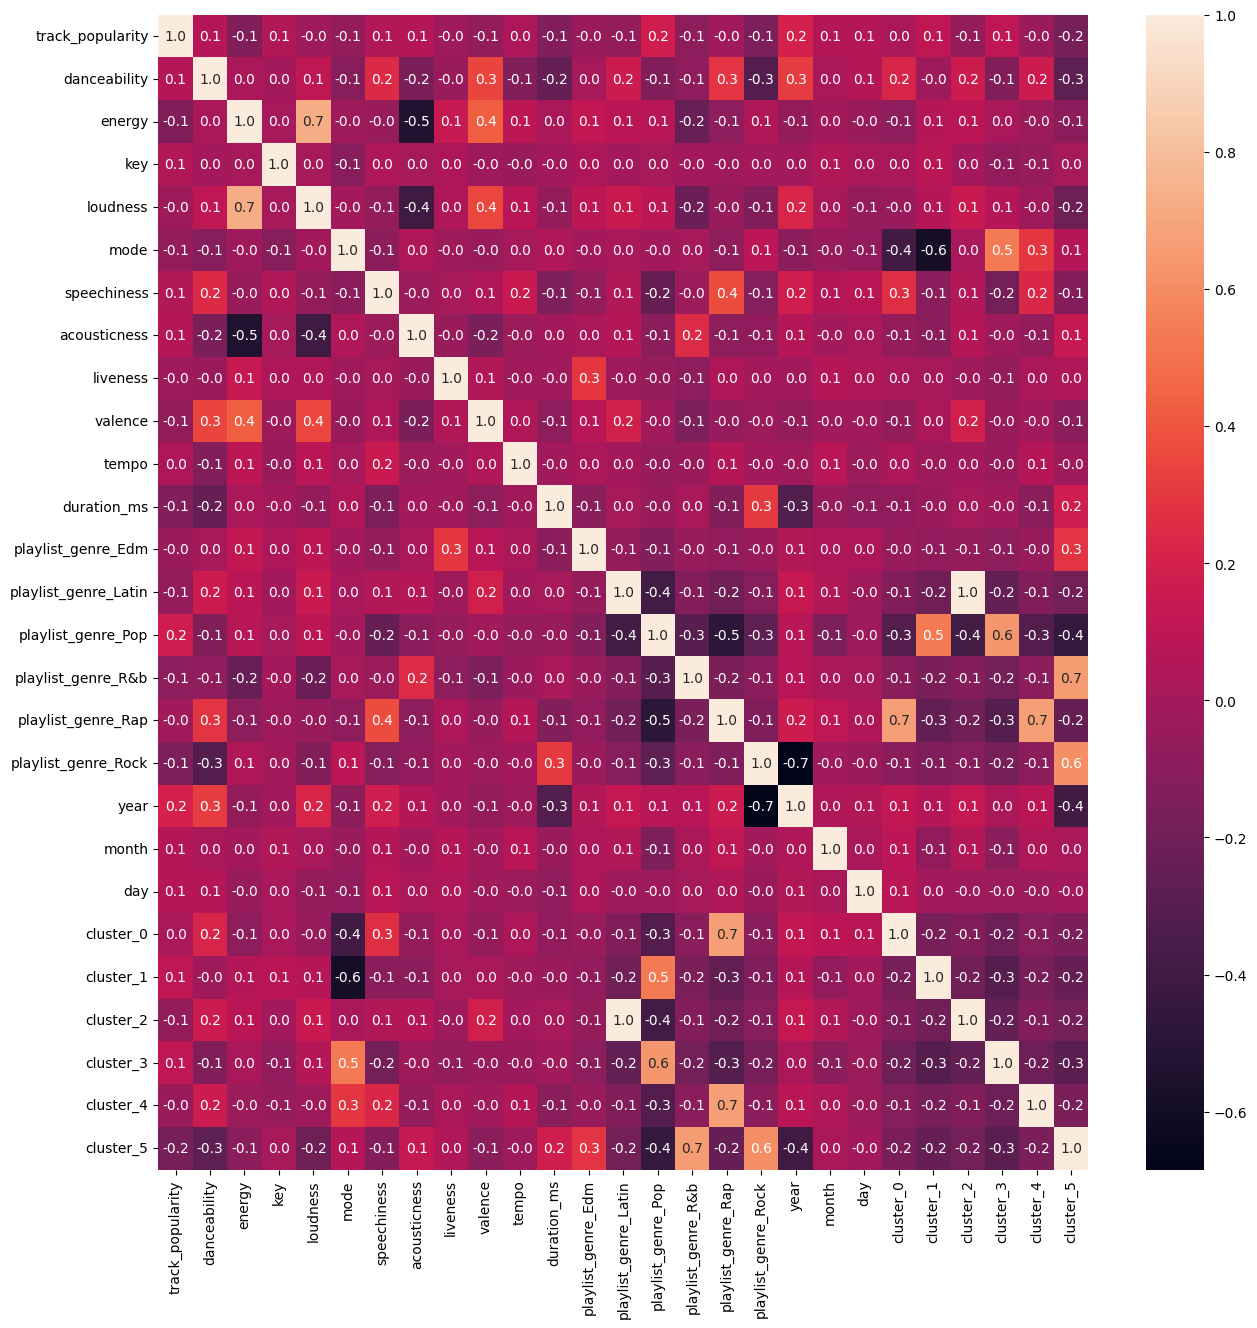

In [41]:
df_corrs_new = df_corr
df_corrs_new['cluster'] = clusters
df_corrs_new = pd.get_dummies(df_corr, columns=['cluster'])
plt.figure(figsize=(15, 15))
sns.heatmap(df_corrs_new.corr(), annot=True, fmt='.1f')
plt.show()

Let's see what number of clusters will be the best

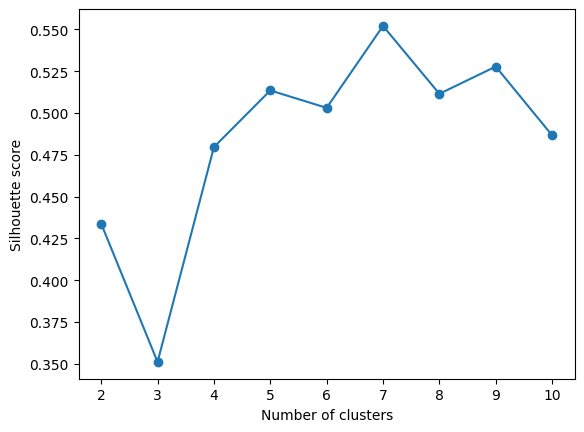

Text(0, 0.5, 'Elbow method')

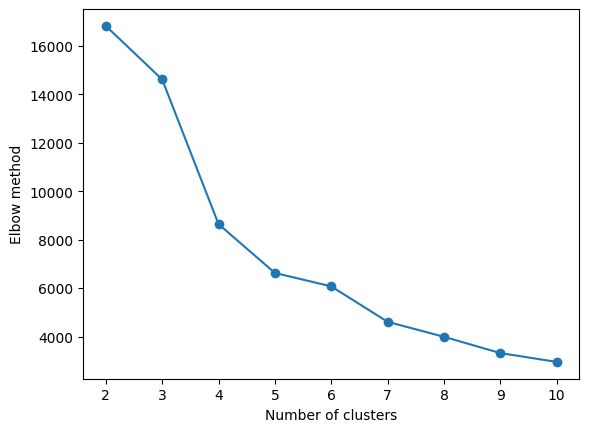

In [66]:
from sklearn.metrics import silhouette_score
scores = []
elbow = []
for i in range(2, 11):
  model = KMeans(n_clusters=i)
  clusters = model.fit_predict(similarity_matrix)
  scores.append(silhouette_score(similarity_matrix, clusters))
  elbow.append(model.inertia_)
plt.plot(range(2, 11), scores, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel("Silhouette score")
plt.show()
plt.plot(range(2, 11), elbow, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel("Elbow method")

As we see, this method is not the best one so let's compare other methods and choose the best one.

### Agglomerative

Let's find the best number of clusters for agglomerative clustering

/usr/local/lib/python3.12/dist-packages/scipy/cluster/hierarchy.py:810: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  return linkage(y, method='ward', metric='euclidean')
/usr/local/lib/python3.12/dist-packages/scipy/cluster/hierarchy.py:810: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  return linkage(y, method='ward', metric='euclidean')
/usr/local/lib/python3.12/dist-packages/scipy/cluster/hierarchy.py:810: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  return linkage(y, method='ward', metric='euclidean')
/usr/local/lib/python3.12/dist-packages/scipy/cluster/hierarchy.py:810: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  return linkage(y, method='ward', metric='euclidea

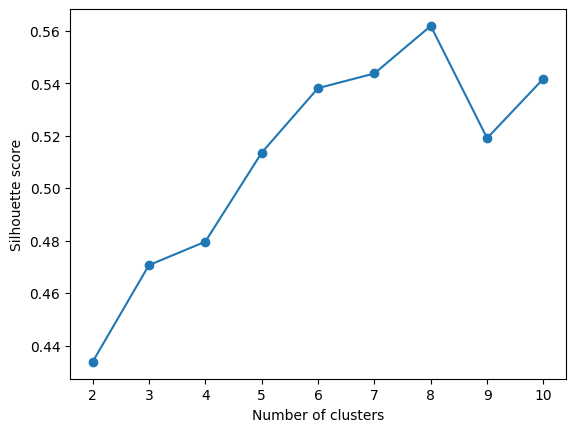

In [63]:
scores = []
for i in range(2, 11):
  model = AgglomerativeClustering(n_clusters=i)
  clusters = model.fit_predict(similarity_matrix)
  scores.append(silhouette_score(similarity_matrix, clusters))
plt.plot(range(2, 11), scores, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel("Silhouette score")
plt.show()


The results are little bit better but similar, so we need to check other methods

### DBSCAN

Let's try it on default settings

In [53]:
from sklearn.cluster import DBSCAN
model = DBSCAN()
clusters = model.fit_predict(similarity_matrix)
print(set(clusters))

{np.int64(-1)}


It went terribly as it did not declare any cluster. Let's try it for bigger epsilon

In [54]:
model = DBSCAN(eps=2)
clusters = model.fit_predict(similarity_matrix)
print(set(clusters))

{np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11)}


As we see, the epsilon has to be bigger, ok so let's try comparing silheute score for number of epsilons

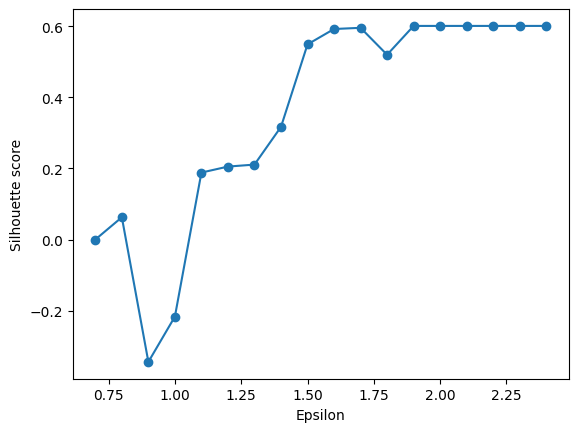

Maximum score: 0.6012592055214916


In [69]:
scores = []
for i in range(2, 20):
  epsilon = 0.5 + 0.1 * i
  model = DBSCAN(eps = epsilon)
  clusters = model.fit_predict(similarity_matrix)
  if len(set(clusters)) > 1:
    scores.append(silhouette_score(similarity_matrix, clusters))
  else:
    scores.append(0)
plt.plot([0.5 + 0.1 * i for i in range(2, 20)], scores, marker='o')
plt.xlabel('Epsilon')
plt.ylabel("Silhouette score")
plt.show()
print(f"Maximum score: {max(scores)}")

The score is a bit higher for eps 1.75

## Clusters

Let's add clusters to our dataset

In [71]:
model  = DBSCAN(eps=1.75)
clusters = model.fit_predict(similarity_matrix)
df_corr['cluster'] = clusters
df_corr

/tmp/ipython-input-4267980476.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_corr['cluster'] = clusters


,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,liveness,valence,...,playlist_genre_Edm,playlist_genre_Latin,playlist_genre_Pop,playlist_genre_R&b,playlist_genre_Rap,playlist_genre_Rock,year,month,day,cluster
0,0.500000,0.632680,0.667346,0.727273,0.680129,1.0,0.010572,0.015932,0.086004,0.391370,...,False,False,True,False,False,False,0.981818,0.454545,0.900000,0
1,0.318182,0.602614,0.425904,0.000000,0.504094,1.0,0.326045,0.261120,0.102930,0.687634,...,False,False,True,False,False,False,0.981818,0.545455,0.333333,0
2,0.318182,0.498039,0.628716,0.636364,0.821136,1.0,0.118212,0.079871,0.090236,0.656505,...,False,False,True,False,False,False,0.981818,0.363636,0.766667,0
3,0.227273,0.601307,0.799335,0.727273,0.753612,1.0,0.135031,0.277700,0.041997,0.538429,...,False,False,True,False,False,False,0.981818,0.272727,0.366667,0
4,0.409091,0.733333,0.886254,0.727273,0.781608,1.0,0.043969,0.201014,0.313445,0.370975,...,False,False,True,False,False,False,0.981818,0.363636,1.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
895,0.090909,0.435294,0.879815,0.545455,0.842229,1.0,0.088419,0.750252,0.957685,0.638257,...,True,False,False,False,False,False,0.981818,0.181818,0.700000,11
896,0.272727,0.448366,0.700612,0.727273,0.754041,1.0,0.126622,0.633151,0.786311,0.524474,...,True,False,False,False,False,False,0.981818,0.636364,0.500000,11
897,0.136364,0.541176,0.727439,0.818182,0.731961,1.0,0.100192,0.016761,0.132551,0.357020,...,True,False,False,False,False,False,0.927273,0.363636,0.633333,11
898,0.045455,0.690196,0.741389,0.909091,0.780493,1.0,0.010452,0.278737,0.210833,0.437527,...,True,False,False,False,False,False,0.963636,1.000000,0.666667,11


In [72]:
df_corr.groupby('cluster').mean()

,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,liveness,valence,...,duration_ms,playlist_genre_Edm,playlist_genre_Latin,playlist_genre_Pop,playlist_genre_R&b,playlist_genre_Rap,playlist_genre_Rock,year,month,day
cluster,,,,,,,,,,,,,,,,,,,,,
-1,0.121212,0.785621,0.788604,0.030303,0.848560,0.0,0.113968,0.141289,0.458020,0.881566,...,0.356777,0.333333,0.0,0.333333,0.0,0.333333,0.0,0.981818,0.757576,0.466667
0,0.234508,0.582681,0.646099,0.444898,0.738052,1.0,0.076348,0.218549,0.145482,0.504098,...,0.278864,0.000000,0.0,1.000000,0.0,0.000000,0.0,0.906419,0.524064,0.478011
1,0.242008,0.616541,0.665353,0.546953,0.738998,0.0,0.087121,0.185058,0.159763,0.530600,...,0.271291,0.000000,0.0,1.000000,0.0,0.000000,0.0,0.924675,0.532323,0.495926
2,0.217782,0.742915,0.596417,0.507493,0.710557,0.0,0.219801,0.186758,0.165268,0.473846,...,0.254145,0.000000,0.0,0.000000,0.0,1.000000,0.0,0.966034,0.664336,0.574725
3,0.176383,0.711679,0.625718,0.434783,0.721643,1.0,0.206450,0.186757,0.171524,0.512181,...,0.245606,0.000000,0.0,0.000000,0.0,1.000000,0.0,0.948419,0.615613,0.466300
4,0.083636,0.421673,0.684022,0.438182,0.686862,1.0,0.048474,0.145350,0.171311,0.525032,...,0.408247,0.000000,0.0,0.000000,0.0,0.000000,1.0,0.471636,0.555556,0.436296
5,0.128788,0.405301,0.643381,0.621212,0.642520,0.0,0.091482,0.232115,0.140338,0.413256,...,0.405145,0.000000,0.0,0.000000,0.0,0.000000,1.0,0.451515,0.587879,0.502222
6,0.179144,0.688530,0.695920,0.518717,0.770001,0.0,0.149973,0.259021,0.162059,0.649734,...,0.285352,0.000000,1.0,0.000000,0.0,0.000000,0.0,0.952228,0.629091,0.468000
7,0.168919,0.702208,0.672407,0.468059,0.764976,1.0,0.121472,0.267776,0.149172,0.616382,...,0.282632,0.000000,1.0,0.000000,0.0,0.000000,0.0,0.965848,0.615479,0.475225


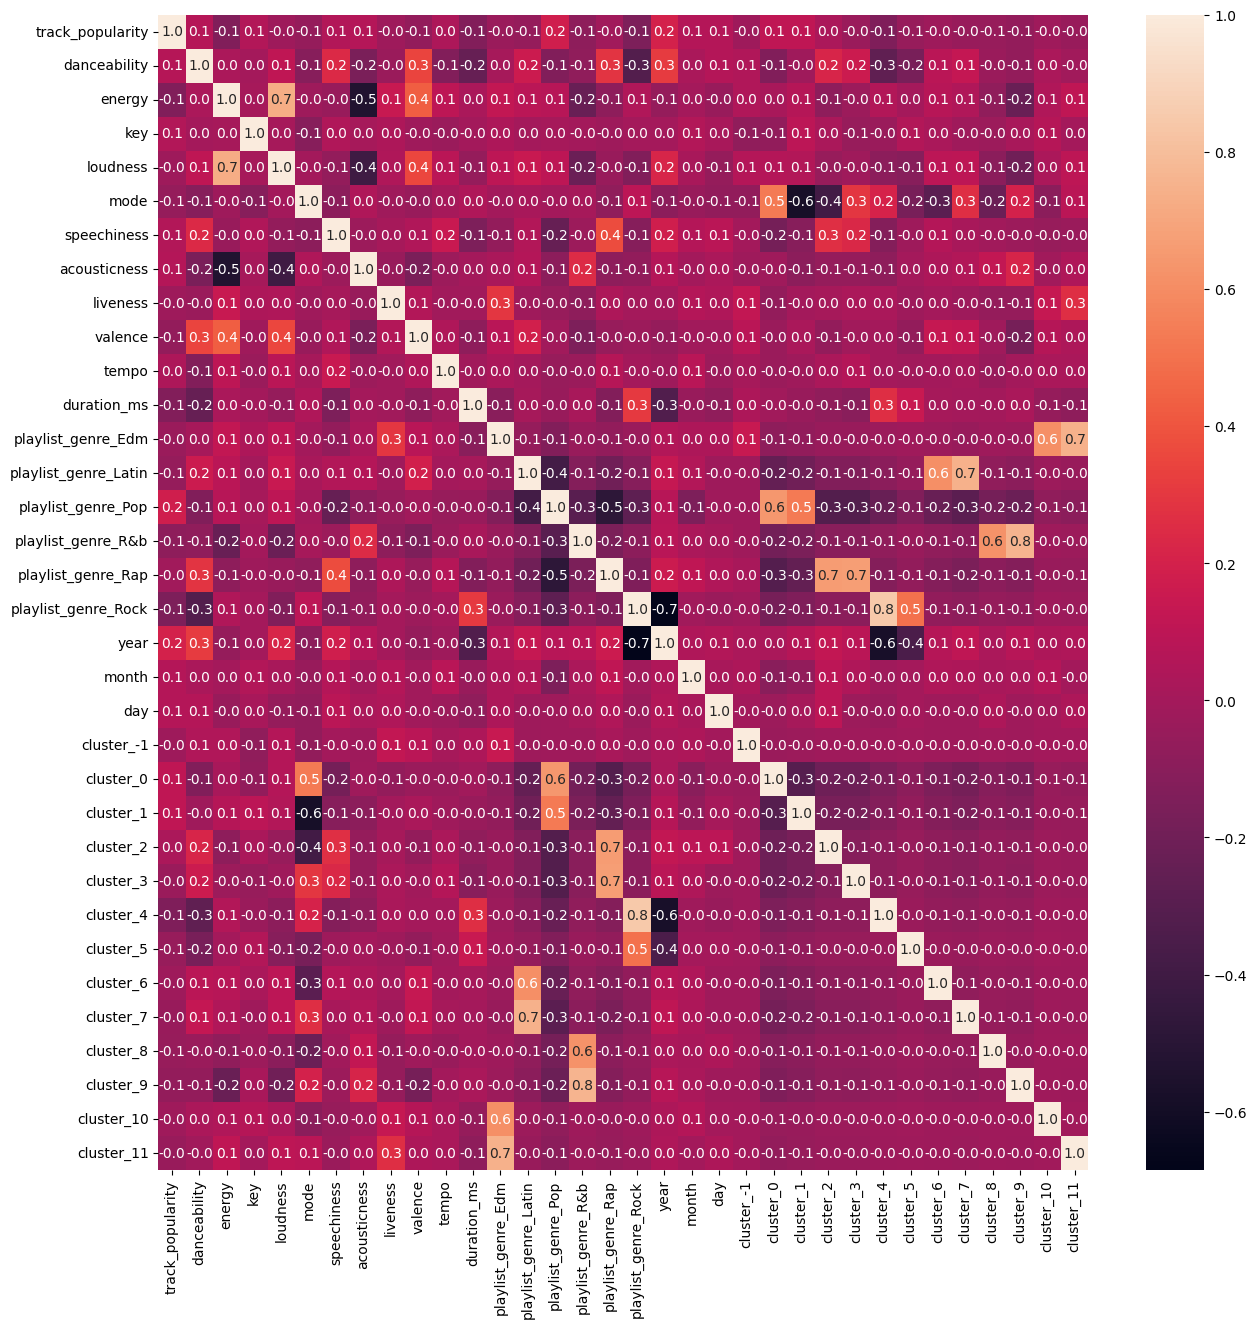

In [73]:
df_corrs_new = pd.get_dummies(df_corr, columns=['cluster'])
plt.figure(figsize=(15, 15))
sns.heatmap(df_corrs_new.corr(), annot=True, fmt='.1f')
plt.show()

Let's see just some of clusters and check if those classifications are good

In [78]:
df[df_corr['cluster'] == 4].head(5)

,Unnamed: 0,track_id,track_name,track_artist,track_popularity,track_album_release_date,playlist_genre,danceability,energy,key,...,tags_tokenized,doc_vector,combined_vector,cluster,image_url,spotify_url,year,month,day,distance
612,612,2IZZqH4K02UIYg5EohpNHF,zombie,Thecranberries,0.181818,1994-10-03,Rock,0.128105,0.621204,0.636364,...,"['another', 'head', 'hangs', 'lowly', 'child',...",[-0.14202067 0.24147537 0.15105194 0.150180...,[-0.14202067 0.24147537 0.15105194 0.150180...,4,https://i.scdn.co/image/ab67616d0000b273e2213d...,https://open.spotify.com/track/2IZZqH4K02UIYg5...,1994,10,03,0.983814
613,613,1lCRw5FEZ1gPDNPzy1K4zW,we are the champions - remastered 2011,Queen,0.000000,1977-10-28,Rock,0.077124,0.432343,0.909091,...,"['ive', 'paid', 'dues', 'time', 'time', 'ive',...",[-1.75410479e-01 1.83482334e-01 1.95978343e-...,[-1.75410479e-01 1.83482334e-01 1.95978343e-...,4,https://i.scdn.co/image/ab67616d0000b2731f7077...,https://open.spotify.com/track/1lCRw5FEZ1gPDNP...,1977,10,28,1.034662
614,614,2LawezPeJhN4AWuSB0GtAU,have you ever seen the rain,Creedenceclearwaterrevival,0.090909,1970-12-07,Rock,0.695425,0.687735,0.000000,...,"['someone', 'told', 'long', 'ago', 'theres', '...",[-1.51376143e-01 2.54083484e-01 3.10092241e-...,[-1.51376143e-01 2.54083484e-01 3.10092241e-...,4,https://i.scdn.co/image/ab67616d0000b27351f311...,https://open.spotify.com/track/2LawezPeJhN4AWu...,1970,12,07,1.034663
615,615,39shmbIHICJ2Wxnk1fPSdz,should i stay or should i go - remastered,Theclash,0.136364,1982,Rock,0.696732,0.833673,0.181818,...,"['whoa', 'ah', 'parlar', 'darling', 'got', 'le...",[-0.10066824 0.35124585 0.21225373 0.147284...,[-1.00668244e-01 3.51245850e-01 2.12253734e-...,4,https://i.scdn.co/image/ab67616d0000b27325a4df...,https://open.spotify.com/track/39shmbIHICJ2Wxn...,1982,None,None,1.005664
618,618,4gMgiXfqyzZLMhsksGmbQV,"another brick in the wall, pt. 2",Pinkfloyd,0.000000,1979-11-30,Rock,0.633987,0.362593,0.000000,...,"['dont', 'need', 'education', 'dont', 'need', ...",[-2.08443329e-01 1.57723948e-01 3.05291027e-...,[-2.08443329e-01 1.57723948e-01 3.05291027e-...,4,https://i.scdn.co/image/ab67616d0000b2735d48e2...,https://open.spotify.com/track/4gMgiXfqyzZLMhs...,1979,11,30,0.963363


In [77]:
df[df_corr['cluster'] == 5].head(5)

,Unnamed: 0,track_id,track_name,track_artist,track_popularity,track_album_release_date,playlist_genre,danceability,energy,key,...,tags_tokenized,doc_vector,combined_vector,cluster,image_url,spotify_url,year,month,day,distance
616,616,2zYzyRzz6pRmhPzyfMEC8s,highway to hell,Ac/dc,0.318182,1979-07-27,Rock,0.475817,0.919519,0.545455,...,"['livin', 'easy', 'lovin', 'free', 'season', '...",[-0.19858196 0.0260861 0.37695372 0.212360...,[-0.19858196 0.0260861 0.37695372 0.212360...,5,https://i.scdn.co/image/ab67616d0000b27351c02a...,https://open.spotify.com/track/2zYzyRzz6pRmhPz...,1979,07,27,0.626044
617,617,2EqlS6tkEnglzr7tkKAAYD,come together - remastered 2009,Thebeatles,0.136364,1969-09-26,Rock,0.423529,0.343277,0.818182,...,"['shoot', 'shoot', 'shoot', 'shoot', 'come', '...",[ 0.01138833 0.07268892 0.20281 0.044984...,[ 0.01138833 0.07268892 0.20281 0.044984...,5,https://i.scdn.co/image/ab67616d0000b273dc3058...,https://open.spotify.com/track/2EqlS6tkEnglzr7...,1969,09,26,0.703208
624,624,54eZmuggBFJbV7k248bTTt,a horse with no name,America,0.045455,1972,Rock,0.581699,0.482777,1.000000,...,"['first', 'part', 'journey', 'looking', 'life'...",[-3.17817867e-01 3.81504714e-01 5.57083413e-...,[-3.17817867e-01 3.81504714e-01 5.57083413e-...,5,https://i.scdn.co/image/ab67616d0000b273ab3b10...,https://open.spotify.com/track/54eZmuggBFJbV7k...,1972,None,None,0.813691
625,625,0vg4WnUWvze6pBOJDTq99k,you're beautiful,Jamesblunt,0.000000,2005-08-08,Rock,0.609150,0.453804,0.000000,...,"['life', 'brilliant', 'life', 'brilliant', 'lo...",[-2.08407730e-01 2.46246770e-01 3.98313850e-...,[-2.08407730e-01 2.46246770e-01 3.98313850e-...,5,https://i.scdn.co/image/ab67616d0000b273105f04...,https://open.spotify.com/track/0vg4WnUWvze6pBO...,2005,08,08,0.763701
628,628,4u7EnebtmKWzUH433cf5Qv,bohemian rhapsody - 2011 mix,Queen,0.363636,1975-11-21,Rock,0.267974,0.373323,0.000000,...,"['real', 'life', 'fantasy', 'caught', 'landsli...",[-0.08351422 0.21863157 0.2511807 0.101766...,[-0.08351422 0.21863157 0.25118071 0.101766...,5,https://i.scdn.co/image/ab67616d0000b273e319ba...,https://open.spotify.com/track/4u7EnebtmKWzUH4...,1975,11,21,0.762072


As we see, cluster number 4 contains songs we can consider "slow rock" and cluster 5 more energetic rock

# Conclusion

Best model from those three is DBSCAN with eps (maximum distance for declaring a neighbour) 1.75. Other methods give similar result of sillheute score around 0.6. The assigned clusters are satysfying and could be useful, for example, for creating a playlist